# Data Selection

Loads the run-wise datacheck table produced by `1_create_total_dcheck.ipynb`,
applies configurable quality cuts (date range, dust, NSB, zenith distance, …),
matches subruns to a source wobble ring, inspects the per-run light-yield
scaling fits (LY_i or LY_b3 — already computed upstream, nothing is fit here),
lets you manually discard bad runs, and exports a single definitive run list.

**Pipeline:**
1. Load run-wise CSV + flat subrun parquet from notebook 1
2. (Optional) filter by date range
3. (Optional) filter by weather / data-quality cuts (incl. LY_b3 completeness)
4. Match pointing to source wobble ring
5. Inspect per-run light-yield fits for the chosen scaling source (LY_i / LY_b3)
6. Manually discard bad runs (hardcoded list in the config cell)
7. Summary plots of the final selection
8. Export the definitive run list to a single file

## Imports

In [1]:
import os, glob, warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm
import copy

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation
import healpy as hp
from scipy.optimize import curve_fit
import utils

pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")

observing_location = EarthLocation.of_site("Roque de los Muchachos")

## Paths and configuration

All tunable parameters are gathered here.

In [2]:
# ── Directory layout (must match notebook 1) ────────────────────────────
ROOT       = Path(os.getcwd())
ROOT_DATA  = ROOT / "data"
DCHECK_DIR = ROOT_DATA / "datachecks"
OUT_DIR    = ROOT_DATA / "selection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Input files from notebook 1 ──────────────────────────────────────────
FNAME_DCHECK_FLAT_SRUNWISE = DCHECK_DIR / "datachecks_flat.parquet"         # subrun-level
FNAME_DCHECK_FLAT_RUNWISE = DCHECK_DIR / "datachecks_flat_runwise.parquet" # run-level

# ── Output file (single, definitive export) ──────────────────────────────
FNAME_SELECTED_RUNS = OUT_DIR / "selected_runs.csv"

# ── Source / wobble ──────────────────────────────────────────────────────
SOURCE_NAME       = "Crab"
WOBBLE_DISTANCE   = 0.4 * u.deg
POINTING_UNCERT   = 0.1 * u.deg

# ── Date filter  (set to None to disable) ────────────────────────────────
DATE_MIN = datetime.fromisoformat("2025-08-17")   # e.g. datetime.fromisoformat("2024-01-01")
DATE_MAX = None   # e.g. datetime.fromisoformat("2025-06-01")

# ── Dust filter  (tng_dust in µg/m³; set to None to disable) ────────────
DUST_MAX = None

# ── Data-quality cuts (set each to None to disable individually) ─────────
ZD_MAX              = None   # max mean zenith distance [deg]
NSB_MAX             = None   # max diffuse_nsb_std  (arbitrary units; None = no cut)
ELAPSED_TIME_MIN    = 120.0  # min run duration [s]; removes very short runs
ELAPSED_TIME_MAX    = 2500.0
DRDI_FIT_ERROR      = False  # True, drop runs where the DRDI fit failed

# ── Light-yield scaling source ────────────────────────────────────────────
# Which quantity the intensity-scaling correction is based on: "ly_i" or "ly_b3".
# IMPORTANT: the subrun-wise linear fit and the resulting scaling factor
# (scaling = inverse of the fitted light yield) are already computed upstream
# (notebook 1) and stored per-run in the datacheck table. This notebook only
# READS those precomputed columns — it never (re-)fits anything.
#
#   LY_SOURCE = "ly_i"   -> uses ly_i_fit_p0/p1, ly_i_scaling, ...
#   LY_SOURCE = "ly_b3"  -> uses ly_b3_fit_p0/p1, ly_b3_scaling, ...
#
# The dataset always has non-NaN LY_i info. LY_b3 is only available for a
# subset of runs, so selecting "ly_b3" additionally constrains the dataset to
# runs where the LY_b3 fit/scaling columns are non-NaN (see Step 4 below).
LY_SOURCE = "ly_b3"   # "ly_i" or "ly_b3"

assert LY_SOURCE in ("ly_i", "ly_b3"), "LY_SOURCE must be 'ly_i' or 'ly_b3'"

# Column names for the precomputed per-run fit / scaling (derived automatically)
LY_FIT_P0_COL      = f"{LY_SOURCE}_fit_p0"
LY_FIT_P1_COL      = f"{LY_SOURCE}_fit_p1"
LY_FIT_U_P0_COL    = f"{LY_SOURCE}_fit_u_p0"
LY_FIT_U_P1_COL    = f"{LY_SOURCE}_fit_u_p1"
LY_FIT_CHI2_COL    = f"{LY_SOURCE}_fit_chi2"
LY_FIT_NDF_COL     = f"{LY_SOURCE}_fit_ndf"
LY_FIT_PVALUE_COL  = f"{LY_SOURCE}_fit_pvalue"
LY_FIT_ERR_FLAG    = f"{LY_SOURCE}_fit_error_flag"
LY_SCALING_COL     = f"{LY_SOURCE}_scaling"
LY_SCALING_ERR_COL = f"{LY_SOURCE}_scaling_err"

# Subrun-level raw column used for the per-run inspection plots (Step 9)
LY_SUBRUN_COL = "light_yield" if LY_SOURCE == "ly_i" else "ly_b3"

print("Configuration loaded.")
print(f"  Source          : {SOURCE_NAME}")
print(f"  Wobble distance : {WOBBLE_DISTANCE}")
print(f"  Date filter     : {DATE_MIN} -> {DATE_MAX}")
print(f"  Dust max        : {DUST_MAX} ug/m3")
print(f"  ZD max          : {ZD_MAX} deg")
print(f"  NSB max         : {NSB_MAX}")
print(f"  Elapsed time    : {ELAPSED_TIME_MIN/60:.1f} - {ELAPSED_TIME_MAX/60:.1f} min")
print(f"  LY scaling src  : {LY_SOURCE}")


Configuration loaded.
  Source          : Crab
  Wobble distance : 0.4 deg
  Date filter     : 2025-08-17 00:00:00 -> None
  Dust max        : None ug/m3
  ZD max          : None deg
  NSB max         : None
  Elapsed time    : 2.0 - 41.7 min
  LY scaling src  : ly_b3


## Step 1 - Load run-wise table

In [3]:
df = pd.read_parquet(FNAME_DCHECK_FLAT_RUNWISE)
df["time"] = pd.to_datetime(df["time"])

print(f"Loaded {len(df):} runs from {FNAME_DCHECK_FLAT_RUNWISE.name}")
print(f"Date range: {df['time'].min().date()} -> {df['time'].max().date()}")
print(f"\nColumns available: {list(df.columns)}\n")
df.head(3)

Loaded 13661 runs from datachecks_flat_runwise.parquet
Date range: 2019-11-24 -> 2026-09-09

Columns available: ['obs_id', 'n_subruns', 'time', 'elapsed_time', 'corrected_elapsed_time', 'zd', 'min_zd', 'max_zd', 'az', 'ra', 'dec', 'events', 'ly_i', 'ly_i_err', 'ly_i_fit_p0', 'ly_i_fit_p1', 'ly_i_fit_u_p0', 'ly_i_fit_u_p1', 'ly_i_fit_chi2', 'ly_i_fit_pvalue', 'ly_i_fit_ndf', 'ly_i_fit_error_flag', 'ly_b3_fit_p0', 'ly_b3_fit_p1', 'ly_b3_fit_u_p0', 'ly_b3_fit_u_p1', 'ly_b3_fit_chi2', 'ly_b3_fit_pvalue', 'ly_b3_fit_ndf', 'ly_b3_fit_error_flag', 'ly_i_scaling', 'ly_i_scaling_err', 'ly_b3_scaling', 'ly_b3_scaling_err', 'ff_events', 'pedestal_events', 'num_contained_mu_rings', 'dcheck_fname', 'dl1_runwise_fname', 'dl2_fname', 'dl3_fname', 'intensity_cut', 'psf_spotsize', 'psf_time', 'alt', 'picture_thresh', 'boundary_thresh', 'diffuse_nsb_std', 'ff_charge_mean', 'ff_charge_stddev', 'ff_rel_time_mean', 'ff_rel_time_stddev', 'pedestal_charge_mean', 'pedestal_charge_stddev', 'pedestal_fraction_p

,obs_id,n_subruns,time,elapsed_time,corrected_elapsed_time,zd,min_zd,max_zd,az,ra,dec,events,ly_i,ly_i_err,ly_i_fit_p0,ly_i_fit_p1,ly_i_fit_u_p0,ly_i_fit_u_p1,ly_i_fit_chi2,ly_i_fit_pvalue,ly_i_fit_ndf,ly_i_fit_error_flag,ly_b3_fit_p0,ly_b3_fit_p1,ly_b3_fit_u_p0,ly_b3_fit_u_p1,ly_b3_fit_chi2,ly_b3_fit_pvalue,ly_b3_fit_ndf,ly_b3_fit_error_flag,ly_i_scaling,ly_i_scaling_err,ly_b3_scaling,ly_b3_scaling_err,ff_events,pedestal_events,num_contained_mu_rings,dcheck_fname,dl1_runwise_fname,dl2_fname,dl3_fname,intensity_cut,psf_spotsize,psf_time,alt,picture_thresh,boundary_thresh,diffuse_nsb_std,ff_charge_mean,ff_charge_stddev,ff_rel_time_mean,ff_rel_time_stddev,pedestal_charge_mean,pedestal_charge_stddev,pedestal_fraction_pulses_above10,pedestal_fraction_pulses_above30,cosmics_rate,cosmics_cleaned_rate,intensity_at_half_peak_rate,cosmics_peak_rate,cosmics_rate_at_422_pe,delta_cosmics_rate_at_422_pe,cosmics_spectral_index,delta_cosmics_spectral_index,ZD_corrected_intensity_at_half_peak_rate,ZD_corrected_cosmics_peak_rate,ZD_corrected_cosmics_rate_at_422_pe,ZD_corrected_delta_cosmics_rate_at_422_pe,ZD_corrected_cosmics_spectral_index,intensity_spectrum_fit_p_value,intensity_at_reference_rate,light_yield,mu_effi_mean,mu_effi_stddev,mu_width_mean,mu_width_stddev,mu_radius_mean,mu_radius_stddev,mu_intensity_mean,mu_hg_peak_sample,mu_hg_peak_sample_stddev,temperature,pressure,humidity,wind_speed,wind_gust,wind_speed_average,tng_dust,tng_seeing,rain,psf_time_since_h,ly_b3,ly_b3_p_value,ly_b3_err
0,1620,78,2019-11-24 02:03:06.030581,1748.229183,1748.229183,8.161790,6.821253,10.085401,148.878323,83.530990,21.910436,3955939,1.182524,0.015343,1.200709,-0.000025,0.002983,0.000003,118.872950,0.000730,74.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.848427,0.001339,NaN,NaN,85926.0,85117.0,5511,DL1_datacheck_20191123.h5,/fefs/aswg/data/real/DL1/20191123/v0.9/tailcut...,/fefs/aswg/data/real/DL2/20191123/v0.10/tailcu...,None,167.865879,33.669998,2021-04-27 09:50:06,81.838210,8.0,4.0,1.695682,74.000481,9.976240,-0.114774,0.447023,2.125320,1.711744,0.002023,1.329415e-06,2262.826314,2250.137475,125.457316,7.611259,2.089421,0.021293,-2.126312,0.061898,125.247601,7.758972,2.098960,0.021391,-2.123044,0.398105,461.022183,1.182524,0.189981,0.016536,0.069552,0.020307,1.068362,0.104288,2315.446199,12.958343,1.461984,7.734081,785.948769,57.756272,15.732949,22.886387,16.967810,0.030000,2.374972,0.0,-12487.543636,NaN,NaN,NaN
1,1621,41,2019-11-24 02:46:26.059253,906.620067,906.620067,15.083848,13.568849,16.473500,115.613595,102.523179,21.593511,2052150,1.203014,0.016647,1.207023,-0.000020,0.004235,0.000007,75.906311,0.000170,37.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.834557,0.001950,NaN,NaN,44548.0,44132.0,2825,DL1_datacheck_20191123.h5,/fefs/aswg/data/real/DL1/20191123/v0.9/tailcut...,/fefs/aswg/data/real/DL2/20191123/v0.10/tailcu...,None,167.487173,33.669998,2021-04-27 09:50:06,74.916152,8.0,4.0,1.739332,75.178228,10.119668,-0.003996,0.413681,2.166009,1.742466,0.001401,1.831546e-07,2263.517073,2251.247325,126.604546,7.661840,2.101790,0.021400,-2.125405,0.061818,125.901028,8.190208,2.135837,0.021744,-2.114132,0.378661,465.023329,1.203014,0.191008,0.015299,0.069208,0.019727,1.067745,0.104456,2346.769497,12.829851,1.434279,7.557294,785.753202,45.419460,13.833727,19.706307,14.351665,0.030000,2.240000,0.0,-12486.938304,NaN,NaN,NaN
2,1622,79,2019-11-24 03:07:34.524597,1779.822174,1779.822174,12.415295,9.746852,15.307223,238.894163,83.675923,22.003294,3981176,1.179730,0.013928,1.184905,-0.000009,0.002252,0.000002,114.420170,0.002294,75.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.849491,0.001231,NaN,NaN,87478.0,86692.0,5449,DL1_datacheck_20191123.h5,/fefs/aswg/data/real/DL1/20191123/v0.9/tailcut...,/fefs/aswg/data/real/DL2/20191123/v0.10/tailcu...,None,166.326705,33.669998,2021-04-27 09:50:06,77.584705,8.0,4.0,1.704936,74.358717,10.006630,-0.086203,0.447612,2.135068,1.718763,0.001772,4.353636e-07,2236.839196,2224.426720,126.118612,7.545428,2.070006,0.019158,-2.127438,0.05

## Step 2 - Dataset overview

Quick look at the key quality variables before applying any cut.

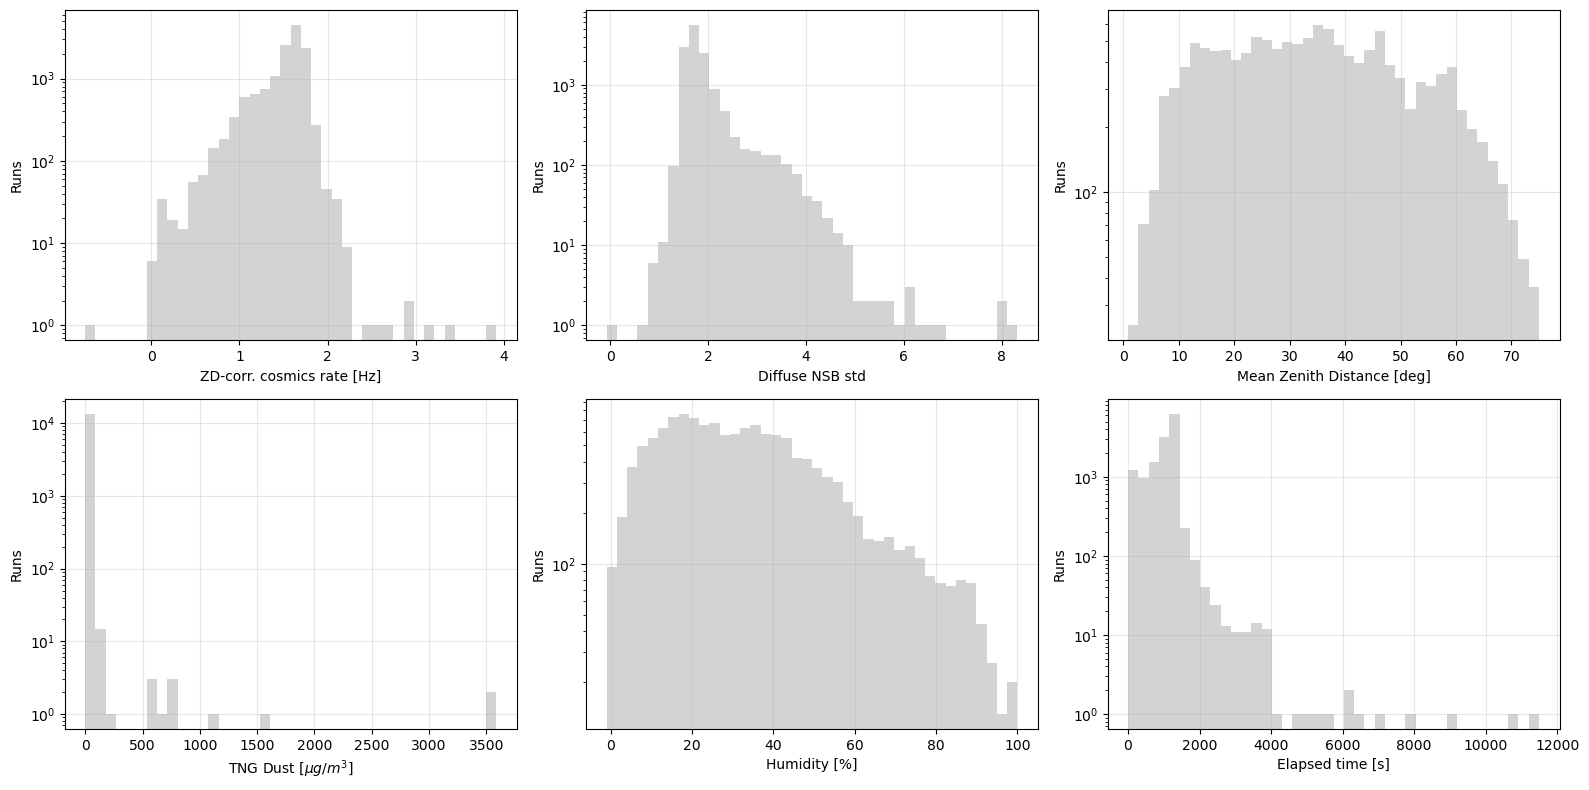

In [4]:
plot_cfg = [
    ("ZD_corrected_cosmics_rate_at_422_pe",  "ZD-corr. cosmics rate [Hz]", 40),
    ("diffuse_nsb_std",                      "Diffuse NSB std",            40),
    ("zd",                                   "Mean Zenith Distance [deg]", 40),
    ("tng_dust",                             "TNG Dust [$\\mu g/m^3$]",    40),
    ("humidity",                             "Humidity [%]",               40),
    ("corrected_elapsed_time",                             "Elapsed time [s]",           40),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, (col, label, bins) in zip(axes.ravel(), plot_cfg):
    if col in df.columns:
        data = df[col].dropna()
        ax.hist(data, bins=bins, color="lightgray", edgecolor="none", alpha=1)
        ax.set(xlabel=label, ylabel="Runs", yscale="log")
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"{col!r}\nnot in table", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3 - (Optional) Date filter

Set `DATE_MIN` / `DATE_MAX` in the configuration cell to restrict the sample to a specific observation period.  
Leave as `None` to keep the full dataset.

In [5]:
df_sel = df.copy()
n_before = len(df_sel)

if DATE_MIN is not None:
    mask_date_min = df_sel["time"] >= pd.Timestamp(DATE_MIN)
    df_sel = df_sel[mask_date_min]
    print(f"  DATE_MIN cut ({DATE_MIN}): {n_before - len(df_sel):,} runs removed  "
          f"-> {len(df_sel):,} remaining")
    n_before = len(df_sel)
else:
    print("  DATE_MIN : no cut applied")

if DATE_MAX is not None:
    mask_date_max = df_sel["time"] <= pd.Timestamp(DATE_MAX)
    df_sel = df_sel[mask_date_max]
    print(f"  DATE_MAX cut ({DATE_MAX}): {n_before - len(df_sel):,} runs removed  "
          f"-> {len(df_sel):,} remaining")
else:
    print("  DATE_MAX : no cut applied")

print(f"After date filter: {len(df_sel):,} runs")


  DATE_MIN cut (2025-08-17 00:00:00): 10,915 runs removed  -> 2,746 remaining
  DATE_MAX : no cut applied
After date filter: 2,746 runs


## Step 4 - (Optional) Dust & weather quality cuts

Filters based on the MAGIC Weather Station data merged in notebook 1.

- **`DUST_MAX`**: maximum TNG dust load in µg/m³.  
  The `tng_dust` column is the `RA` sensor from the WS (`Rain/Dust Activity` index).  
  A conservative clear-night threshold is **100 µg/m³**; relax to e.g. 500 during winter.  
  Set to `None` to skip this cut entirely.
- **`NSB_MAX`**: cap on the diffuse NSB standard deviation (moonlight / clouds proxy).
- **`ZD_MAX`**: maximum mean zenith distance in degrees (affects effective area & threshold).
- **`ELAPSED_TIME_MIN`**: removes stub runs (e.g. aborted runs < 2 min).
- **`DRDI_FIT_ERROR`**: drops runs where the intra-run rate stability fit failed.
- **LY_b3 completeness**: if `LY_SOURCE = "ly_b3"`, runs whose precomputed LY_b3
  fit/scaling columns are NaN (LY_b3 not available for that run) are dropped.
  This cut is skipped entirely when `LY_SOURCE = "ly_i"`, since LY_i is always
  present.

In [6]:
n_before = len(df_sel)
cut_log = []

# ── Dust ─────────────────────────────────────────────────────────────────
if DUST_MAX is not None and "tng_dust" in df_sel.columns:
    mask_dust = df_sel["tng_dust"].isna() | (df_sel["tng_dust"] <= DUST_MAX)
    n_cut = n_before - mask_dust.sum()
    df_sel = df_sel[mask_dust]
    cut_log.append(f"  Dust ≤ {DUST_MAX} ug/m3        : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
    n_before = len(df_sel)
elif DUST_MAX is not None:
    cut_log.append("  Dust cut requested but tng_dust column not found - skipped")
else:
    cut_log.append("  Dust cut : disabled (DUST_MAX = None)")

# ── NSB ──────────────────────────────────────────────────────────────────
if NSB_MAX is not None and "diffuse_nsb_std" in df_sel.columns:
    mask_nsb = df_sel["diffuse_nsb_std"].isna() | (df_sel["diffuse_nsb_std"] <= NSB_MAX)
    n_cut = n_before - mask_nsb.sum()
    df_sel = df_sel[mask_nsb]
    cut_log.append(f"  NSB_std ≤ {NSB_MAX}              : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
    n_before = len(df_sel)
else:
    cut_log.append("  NSB cut  : disabled (NSB_MAX = None)")

# ── Zenith distance ──────────────────────────────────────────────────────
if ZD_MAX is not None and "zd" in df_sel.columns:
    mask_zd = df_sel["zd"].isna() | (df_sel["zd"] <= ZD_MAX)
    n_cut = n_before - mask_zd.sum()
    df_sel = df_sel[mask_zd]
    cut_log.append(f"  ZD ≤ {ZD_MAX}°                  : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
    n_before = len(df_sel)
else:
    cut_log.append("  ZD cut   : disabled (ZD_MAX = None)")

# ── Elapsed time ─────────────────────────────────────────────────────────
if "telapsed" in df_sel.columns and (ELAPSED_TIME_MIN is not None or ELAPSED_TIME_MAX is not None):
    # Apply min and max filters dynamically
    mask_tel = pd.Series(True, index=df_sel.index)
    if ELAPSED_TIME_MIN is not None:
        mask_tel &= df_sel["telapsed"] >= ELAPSED_TIME_MIN
    if ELAPSED_TIME_MAX is not None:
        mask_tel &= df_sel["telapsed"] <= ELAPSED_TIME_MAX

    n_cut = n_before - mask_tel.sum()
    df_sel = df_sel[mask_tel]

    # Construct a concise log string matching your style
    cond_str = f"{ELAPSED_TIME_MIN or 0} ≤ telapsed ≤ {ELAPSED_TIME_MAX or 'infinite'}"
    cut_log.append(f"  {cond_str:<22} : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
    n_before = len(df_sel)
else:
    cut_log.append("  Elapsed time cut : disabled")

# ── DRDI fit error flag ───────────────────────────────────────────────────
if DRDI_FIT_ERROR and "run_drdi_fit_error_flag" in df_sel.columns:
    mask_drdi = ~df_sel["run_drdi_fit_error_flag"].astype(bool)
    n_cut = n_before - mask_drdi.sum()
    df_sel = df_sel[mask_drdi]
    cut_log.append(f"  DRDI fit error removed         : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
    n_before = len(df_sel)
else:
    cut_log.append("  DRDI fit error cut : disabled")

# ── LY_b3 completeness (only applied when LY_SOURCE == "ly_b3") ──────────
if LY_SOURCE == "ly_b3":
    required_cols = [LY_FIT_P0_COL, LY_FIT_P1_COL, LY_SCALING_COL]
    mask_b3 = df_sel[required_cols].notna().all(axis=1)
    n_cut = n_before - mask_b3.sum()
    df_sel = df_sel[mask_b3]
    cut_log.append(f"  LY_b3 completeness (non-NaN)   : -{n_cut:>5,} runs  -> {len(df_sel):,} remaining")
else:
    cut_log.append("  LY_b3 completeness cut : not applicable (LY_SOURCE = 'ly_i')")

print("\n── Quality cut summary ──────────────────────────────────────────────")
for line in cut_log:
    print(line)
print("─────────────────────────────────────────────────────────────────────")
print(f"After quality cuts: {len(df_sel):,} runs  "
      f"({len(df_sel)/len(df)*100:.1f}% of full dataset)")



── Quality cut summary ──────────────────────────────────────────────
  Dust cut : disabled (DUST_MAX = None)
  NSB cut  : disabled (NSB_MAX = None)
  ZD cut   : disabled (ZD_MAX = None)
  Elapsed time cut : disabled
  DRDI fit error cut : disabled
  LY_b3 completeness (non-NaN)   : -2,634 runs  -> 112 remaining
─────────────────────────────────────────────────────────────────────
After quality cuts: 112 runs  (0.8% of full dataset)


## Step 5 - AltAz -> RA/Dec conversion and wobble-ring matching

In [8]:
# Wobble ring matching
source_coord = SkyCoord.from_name(SOURCE_NAME)
run_coords   = SkyCoord(ra=df_sel["ra"].to_numpy() * u.deg, dec=df_sel["dec"].to_numpy() * u.deg)
separation   = source_coord.separation(run_coords)

min_dist = WOBBLE_DISTANCE - POINTING_UNCERT
max_dist = WOBBLE_DISTANCE + POINTING_UNCERT
mask_wobble = (separation >= min_dist) & (separation <= max_dist)

df_sel["separation_deg"] = separation.deg
df_sel = df_sel[mask_wobble].copy()

print(f"Wobble ring [{min_dist:.2f}, {max_dist:.2f}] around {SOURCE_NAME}")
print(f"  Source: RA={source_coord.ra.deg:.3f} deg, Dec={source_coord.dec.deg:.3f} deg")
print(f"  Runs matching wobble ring: {len(df_sel):,}")
print(f"  Total elapsed time       : {df_sel["corrected_elapsed_time"].sum()/3600:.2f} h")

Wobble ring [0.30 deg, 0.50 deg] around Crab
  Source: RA=83.632 deg, Dec=22.017 deg
  Runs matching wobble ring: 112
  Total elapsed time       : 32.10 h


## Step 6 - Pointing diagnostics

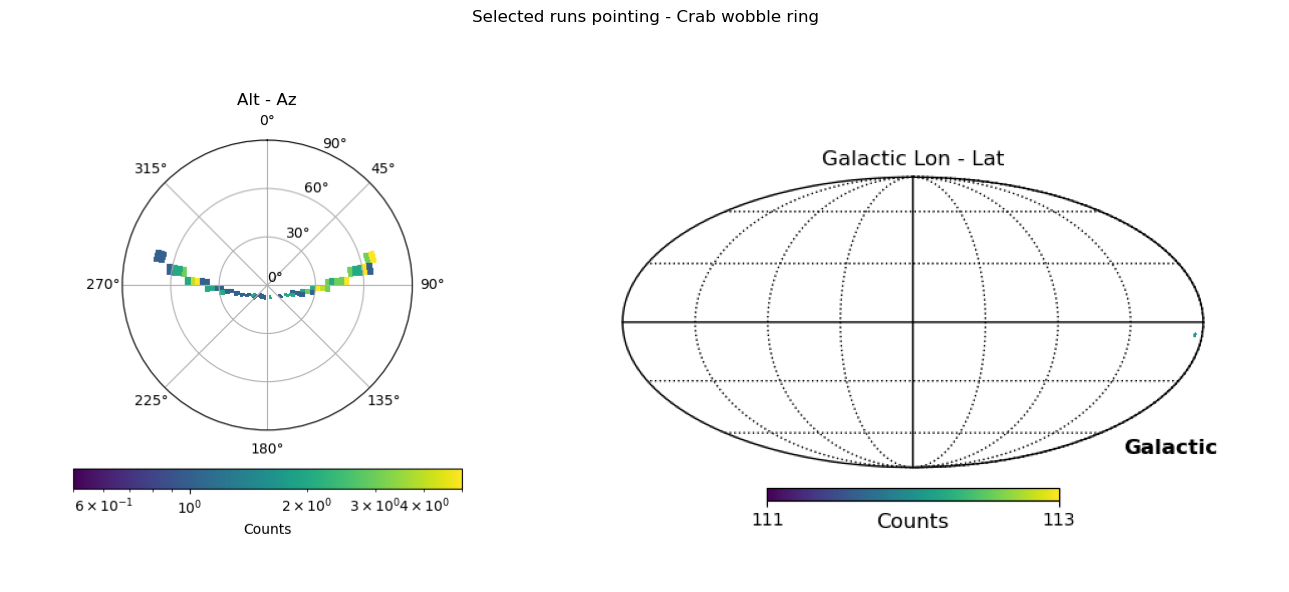

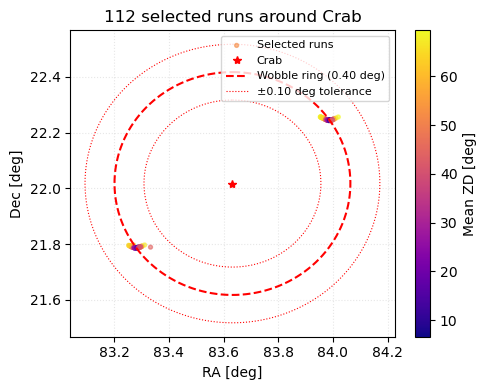

In [9]:
# ── AltAz polar map ──────────────────────────────────────────────────────
theta = np.radians(np.array(df_sel["az"].to_numpy()) % 360.0)
r     = df_sel["zd"].to_numpy()

counts, theta_edges, r_edges = np.histogram2d(
    theta, r, bins=[60, 30], range=[[0, 2 * np.pi], [0, 90]]
)
Thetas, Rs = np.meshgrid(theta_edges, r_edges)

# ── HEALPix sky map ──────────────────────────────────────────────────────
healpix_map = np.zeros(hp.nside2npix(32))
theta_hp = np.radians(90.0 - df_sel["dec"].values)
phi_hp   = np.radians(df_sel["ra"].values)
np.add.at(healpix_map, hp.ang2pix(32, theta_hp, phi_hp), 1)
healpix_map[healpix_map == 0] = np.nan

fig_polar, ax_polar = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
pc = ax_polar.pcolormesh(Thetas, Rs, counts.T, cmap="viridis", norm=LogNorm(vmin=0.5))
plt.colorbar(pc, orientation="horizontal", pad=0.1, label="Counts")
ax_polar.set(theta_zero_location="N", theta_direction=-1,
             rmax=90, title="Alt - Az", rticks=[90, 60, 30, 0],
             yticklabels=["90°", "60°", "30°", "0°"])
fig_polar.canvas.draw()
plt.close(fig_polar)

fig_hp = plt.figure(figsize=(6, 4), facecolor="white")
cmap_hp = copy.copy(plt.get_cmap("viridis"))
cmap_hp.set_under("white")
hp.mollview(healpix_map, coord=["C", "G"], title="Galactic Lon - Lat",
            unit="\nCounts", cmap=cmap_hp, norm="log", hold=True)
hp.graticule(dpar=30, dmer=45, coord="G", local=True)
fig_hp.canvas.draw()
plt.close(fig_hp)

fig_final, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 6), facecolor="white",
    gridspec_kw={"width_ratios": [1, 1.5]}
)
ax1.imshow(fig_polar.canvas.buffer_rgba()); ax2.imshow(fig_hp.canvas.buffer_rgba())
ax1.axis("off"); ax2.axis("off")
pos2 = ax2.get_position()
ax2.set_position([pos2.x0, pos2.y0 + 0.05, pos2.width, pos2.height])
plt.suptitle(f"Selected runs pointing - {SOURCE_NAME} wobble ring", y=1.01)
plt.tight_layout()
plt.show()

# ── Wobble ring scatter ───────────────────────────────────────────────────
azimuths_ring = np.linspace(0, 360, 300) * u.deg
circle = source_coord.directional_offset_by(azimuths_ring, WOBBLE_DISTANCE)
circle_in  = source_coord.directional_offset_by(azimuths_ring, WOBBLE_DISTANCE - POINTING_UNCERT)
circle_out = source_coord.directional_offset_by(azimuths_ring, WOBBLE_DISTANCE + POINTING_UNCERT)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df_sel["ra"], df_sel["dec"], s=8, alpha=0.6,
           c=df_sel["zd"], cmap="plasma", label="Selected runs")
ax.plot(source_coord.ra.deg, source_coord.dec.deg, "*r", label=SOURCE_NAME)
ax.plot(circle.ra.deg, circle.dec.deg, "r--", lw=1.5, label=f"Wobble ring ({WOBBLE_DISTANCE.value:.2f} deg)")
ax.plot(circle_in.ra.deg, circle_in.dec.deg, "r:", lw=0.8)
ax.plot(circle_out.ra.deg, circle_out.dec.deg, "r:", lw=0.8,
        label=f"±{POINTING_UNCERT.value:.2f} deg tolerance")
sm = plt.cm.ScalarMappable(cmap="plasma",
     norm=plt.Normalize(df_sel["zd"].min(), df_sel["zd"].max()))
plt.colorbar(sm, ax=ax, label="Mean ZD [deg]")
ax.set(xlabel="RA [deg]", ylabel="Dec [deg]", title=f"{len(df_sel)} selected runs around {SOURCE_NAME}")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3, ls=":")
plt.tight_layout()
plt.show()

## Step 7 - Timeline & dust inspection

Visualise the selected runs over time together with key quality variables.
This is particularly useful to check whether cuts on dust or date are sensible.

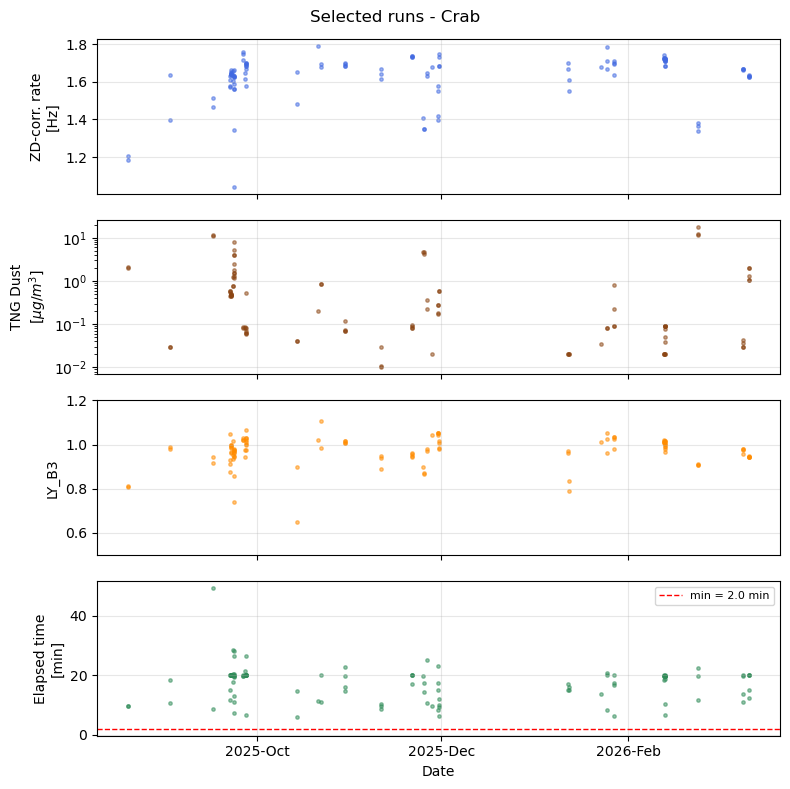

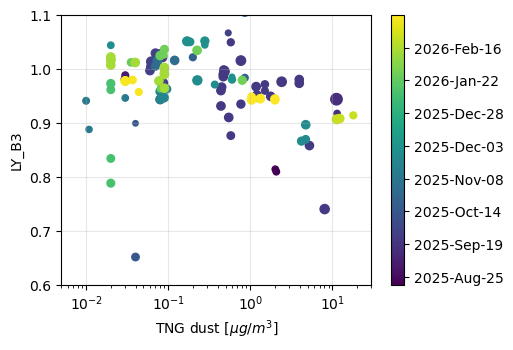

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

ts = df_sel["time"]

# Panel 1 – ZD-corrected cosmics rate
axes[0].scatter(ts, df_sel["ZD_corrected_cosmics_rate_at_422_pe"], s=6, alpha=0.5, color="royalblue")
axes[0].set(ylabel="ZD-corr. rate\n[Hz]")
axes[0].grid(alpha=0.3)

# Panel 2 – Dust
if "tng_dust" in df_sel.columns:
    axes[1].scatter(ts, df_sel["tng_dust"], s=6, alpha=0.5, color="saddlebrown")
    if DUST_MAX is not None:
        axes[1].axhline(DUST_MAX, color="red", lw=1, ls="--",
                        label=f"DUST_MAX = {DUST_MAX}")
        axes[1].legend(fontsize=8)
    axes[1].set(ylabel="TNG Dust\n[$\\mu g/m^3$]", yscale="log")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "tng_dust column not available",
                 ha="center", va="center", transform=axes[1].transAxes, color="gray")

# Panel 3 – Light yield (follows the LY_SOURCE selected in the config cell)
ly_plot_col = LY_SOURCE if LY_SOURCE in df_sel.columns else "light_yield"
if ly_plot_col in df_sel.columns:
    axes[2].scatter(ts, df_sel[ly_plot_col], s=6, alpha=0.5, color="darkorange")
    axes[2].set(ylabel=f"{LY_SOURCE.upper()}", ylim=(0.5, 1.2))
    axes[2].grid(alpha=0.3)

# Panel 4 – Elapsed time per run
axes[3].scatter(ts, df_sel["corrected_elapsed_time"] / 60, s=6, alpha=0.5, color="seagreen")
if ELAPSED_TIME_MIN is not None:
    axes[3].axhline(ELAPSED_TIME_MIN / 60, color="red", lw=1, ls="--",
                    label=f"min = {ELAPSED_TIME_MIN/60:.1f} min")
    axes[3].legend(fontsize=8)
axes[3].set(ylabel="Elapsed time\n[min]", xlabel="Date")
axes[3].grid(alpha=0.3)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%b"))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

fig.suptitle(f"Selected runs - {SOURCE_NAME}")
plt.gcf().autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

converted_dates = mdates.date2num(df_sel["time"])

fig, ax = plt.subplots(figsize=(5, 3.5))
sc = ax.scatter(df_sel["tng_dust"], df_sel[ly_plot_col], marker=".", s=df_sel["corrected_elapsed_time"]**0.7, c=converted_dates)
cbar = fig.colorbar(sc, ax=ax)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%b-%d"))
ax.grid(alpha=0.3)
ax.set(xlabel="TNG dust [$\\mu g /m^3$]", ylabel=f"{LY_SOURCE.upper()}", ylim=(0.6, 1.1), xlim=(0.5e-2, 30), xscale="log")
plt.show()


## Step 8 - Candidate run list (before manual discard)

This is the candidate list after all automated cuts and wobble matching, but
**before** the manual discard step below. Use it together with the per-run
light-yield plots in Step 9 to decide which runs (if any) to add to
`MANUAL_DISCARD_RUNS` in the config cell.

In [11]:
# Sort by date
df_sel = df_sel.sort_values("time").reset_index(drop=True)

run_list = df_sel[["obs_id", "time", "n_subruns", "corrected_elapsed_time",
                   "zd", "separation_deg", "ZD_corrected_cosmics_rate_at_422_pe",
                   "diffuse_nsb_std", "tng_dust", LY_SOURCE, LY_SCALING_COL]]

print("── Candidate run list ───────────────────────────────────────────────")
for _, row in run_list.iterrows():
    date_str = str(row["time"]).split("T")[0].split(" ")[0]
    print(f"  {date_str}  run {int(row['obs_id']):6d}  "
          f"zd={row['zd']:5.1f} deg  t={row['corrected_elapsed_time']/60:5.1f} "
          f"min dust={row['tng_dust']:02.1f} ug/m3  {LY_SOURCE}={row[LY_SOURCE]:.3f} "
          f"scaling={row[LY_SCALING_COL]:.3f}")

print("─────────────────────────────────────────────────────────────────────")
print(f"Total candidates: {len(df_sel):,} runs  |  {df_sel['corrected_elapsed_time'].sum()/3600:.2f} h  |  "
      f"{df_sel['n_subruns'].sum():,} subruns")

print(f"\nCandidate run numbers:")
print(sorted(df_sel["obs_id"].astype(int).tolist()))


── Candidate run list ───────────────────────────────────────────────
  2025-08-19  run  21404  zd= 52.3 deg  t=  9.7 min dust=2.1 ug/m3  ly_b3=0.809 scaling=1.237
  2025-08-19  run  21405  zd= 49.6 deg  t=  9.5 min dust=2.0 ug/m3  ly_b3=0.814 scaling=1.297
  2025-09-02  run  21726  zd= 48.2 deg  t= 18.5 min dust=0.0 ug/m3  ly_b3=0.981 scaling=1.020
  2025-09-02  run  21727  zd= 44.4 deg  t= 10.8 min dust=0.0 ug/m3  ly_b3=0.988 scaling=1.025
  2025-09-16  run  21816  zd= 37.8 deg  t=  8.7 min dust=11.5 ug/m3  ly_b3=0.917 scaling=1.085
  2025-09-16  run  21817  zd= 31.9 deg  t= 49.4 min dust=11.3 ug/m3  ly_b3=0.944 scaling=1.058
  2025-09-22  run  21921  zd= 68.9 deg  t= 11.8 min dust=0.6 ug/m3  ly_b3=1.049 scaling=0.980
  2025-09-22  run  21922  zd= 64.8 deg  t= 14.9 min dust=0.6 ug/m3  ly_b3=0.876 scaling=1.141
  2025-09-22  run  21923  zd= 60.6 deg  t= 20.1 min dust=0.5 ug/m3  ly_b3=0.910 scaling=1.098
  2025-09-22  run  21924  zd= 56.6 deg  t= 20.0 min dust=0.4 ug/m3  ly_b3=0.931 sc

## Step 9 - Per-run light-yield fit inspection

For each candidate run, plot the subrun-wise light yield (`ly_i` / `light_yield`
or `ly_b3`, depending on `LY_SOURCE`) over time together with the **precomputed**
linear fit already stored in the datacheck table
(`{LY_SOURCE}_fit_p0`/`_fit_p1`). **No fit is computed in this notebook** — the
fit line shown is exactly the one produced upstream, and the scaling factor
(`{LY_SOURCE}_scaling`, the inverse of the fitted light yield) is annotated on
each panel. A green dashed line indicates a successful fit
(`{LY_SOURCE}_fit_error_flag` is False); red means the fit failed and the
per-run median is shown as a dotted line instead. The TNG dust value is
annotated in the top-left corner (green < 1.5, orange 1.5–3.0, red > 3.0 µg m⁻³).

Use this to decide which `obs_id`s to add to `MANUAL_DISCARD_RUNS` in the
config cell, then re-run from Step 10 onward.

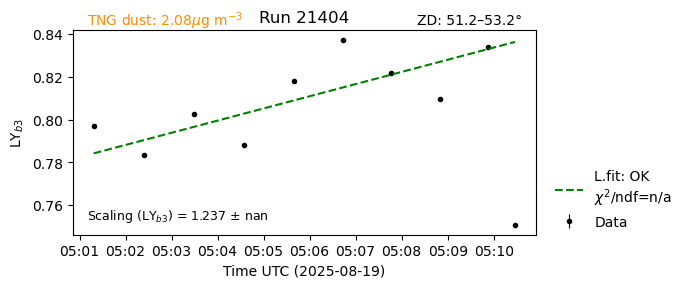

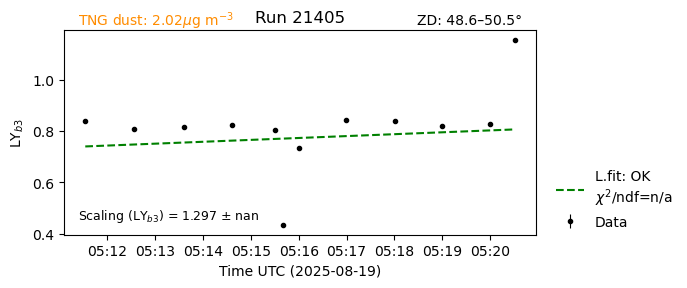

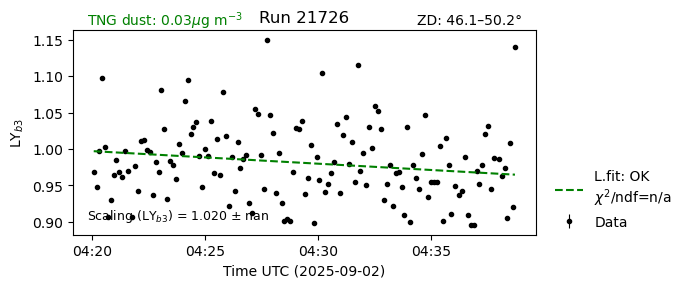

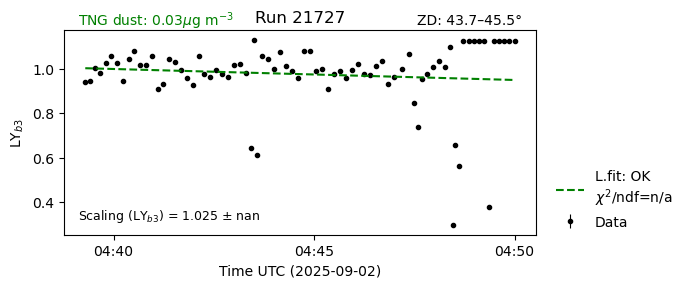

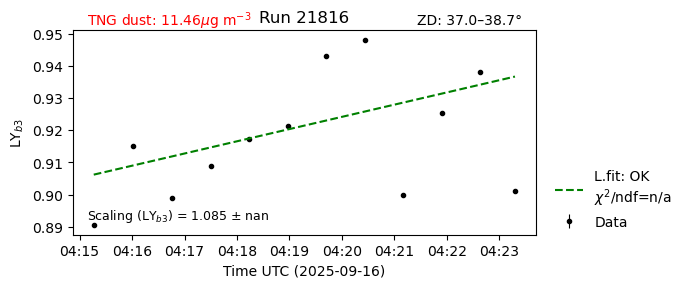

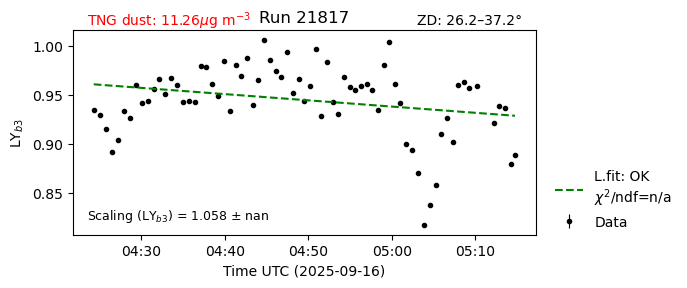

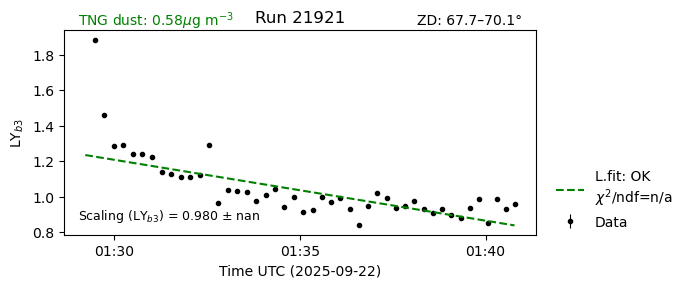

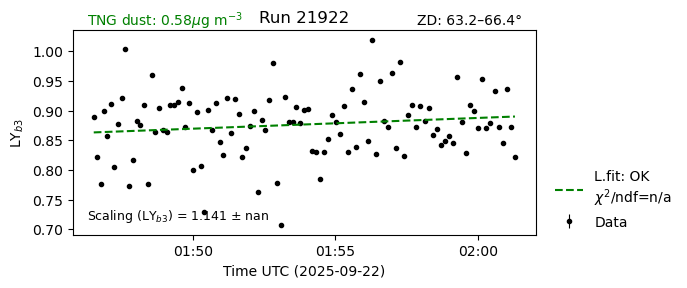

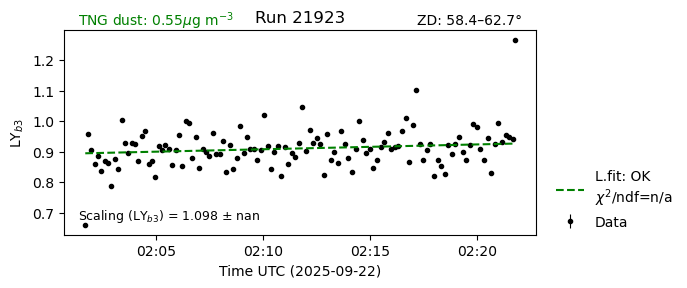

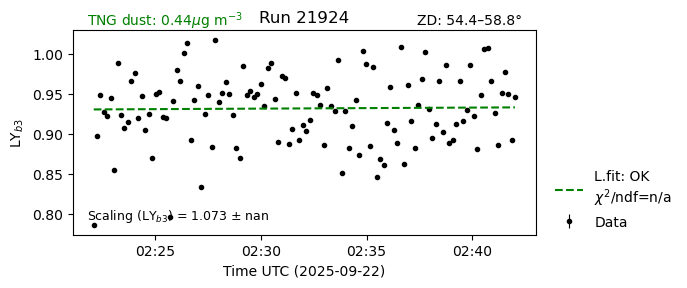

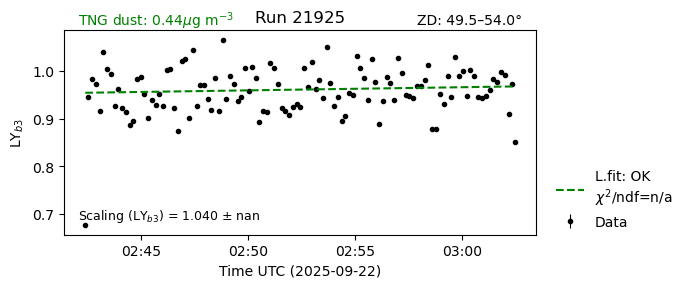

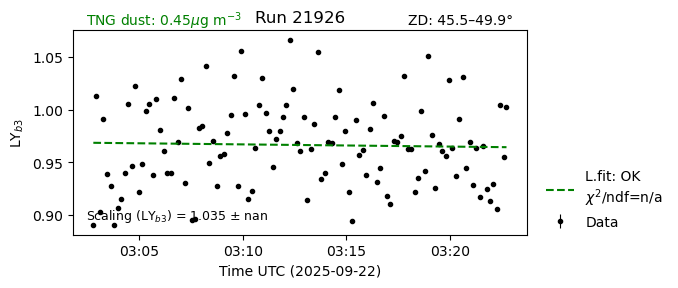

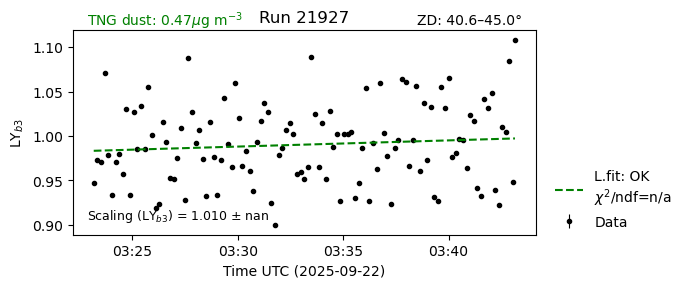

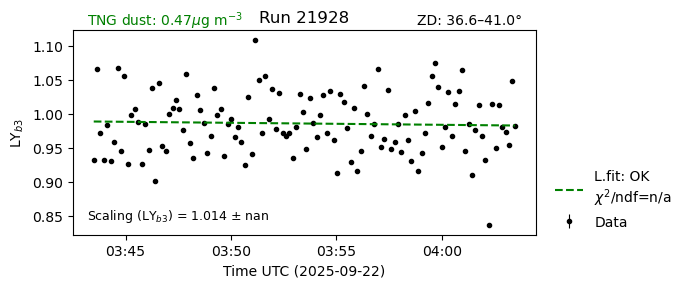

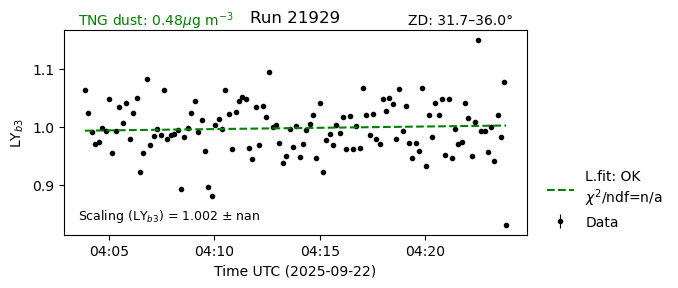

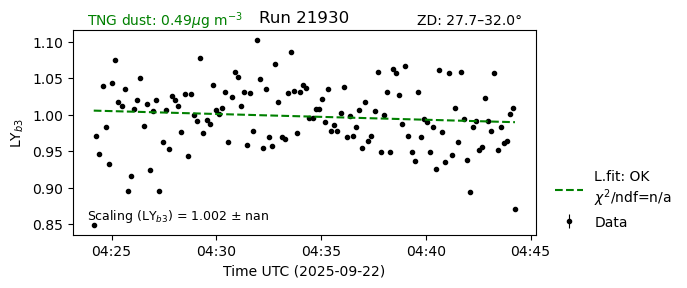

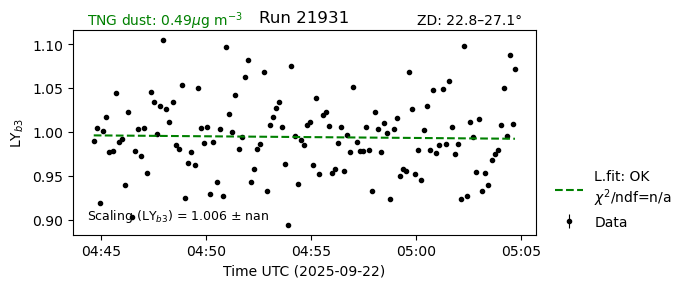

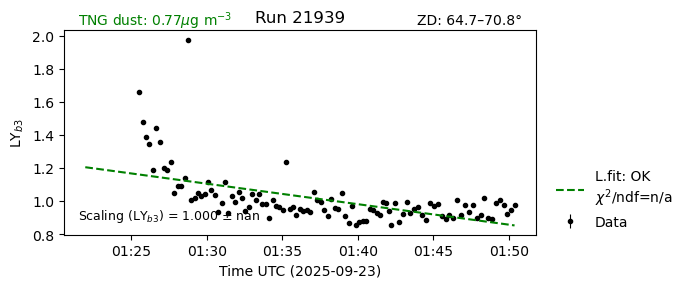

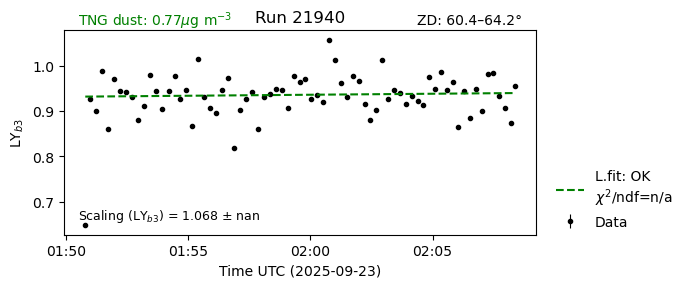

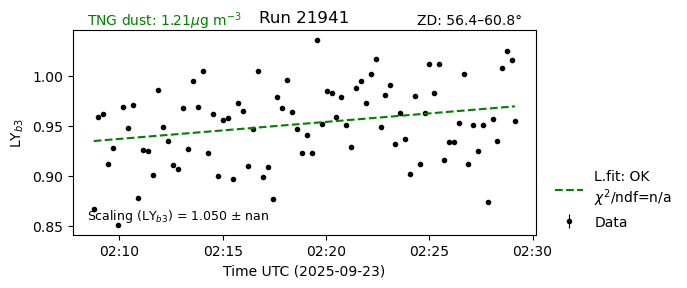

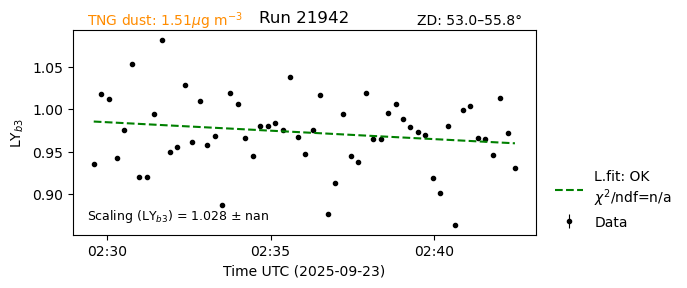

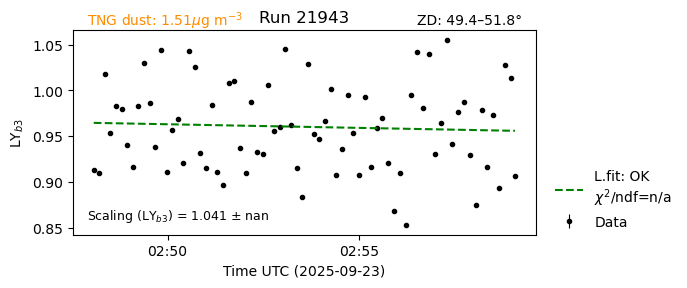

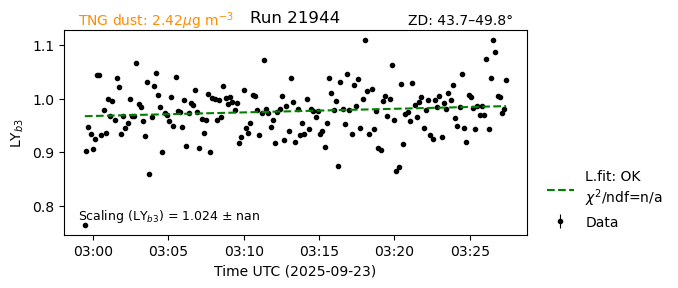

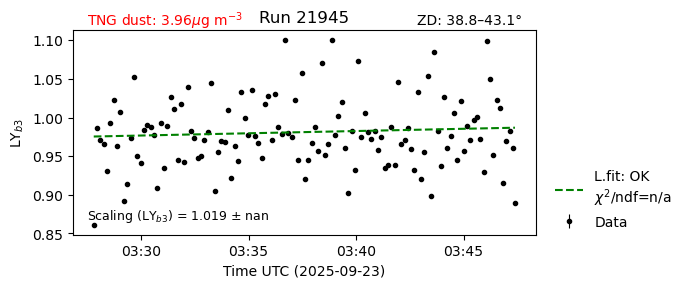

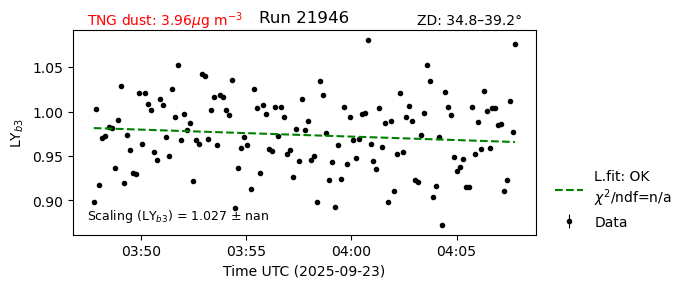

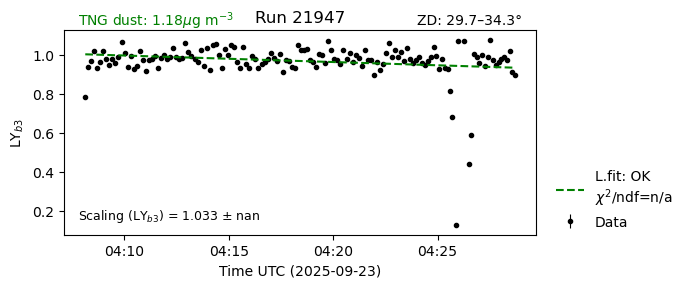

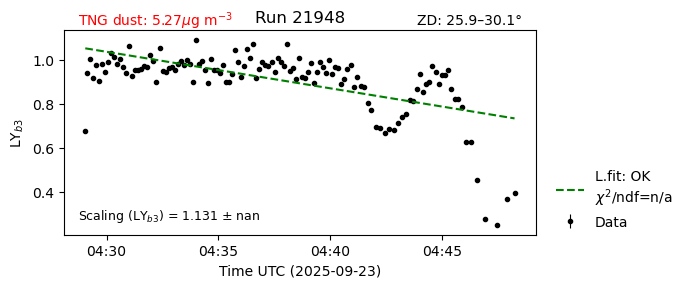

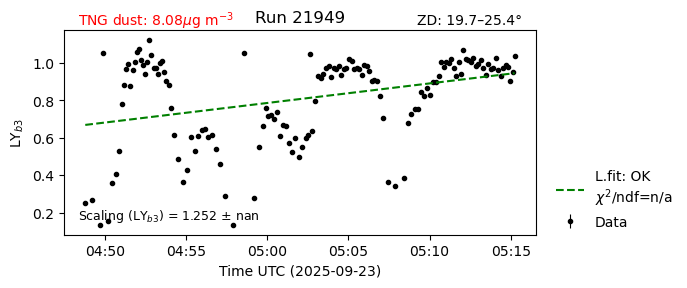

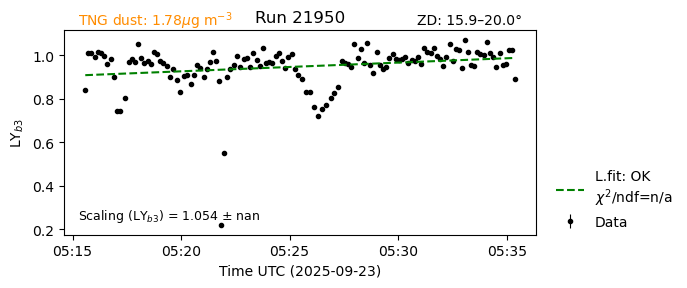

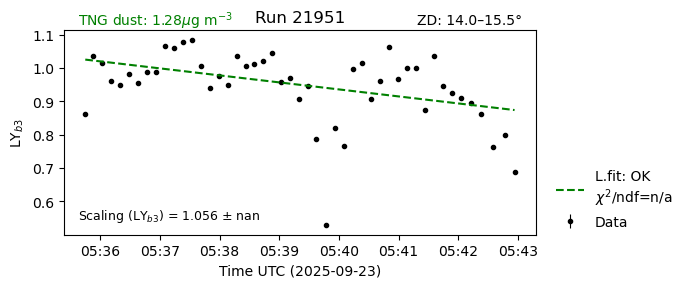

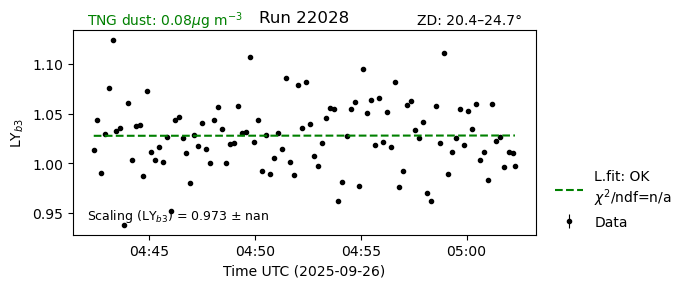

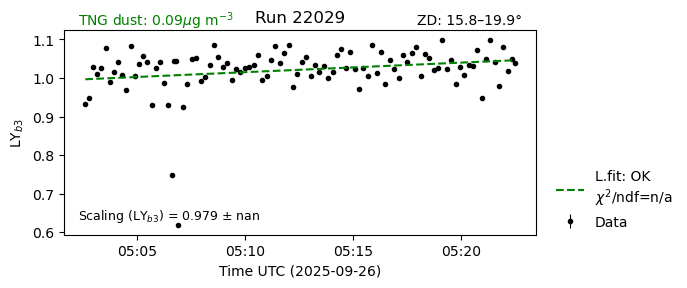

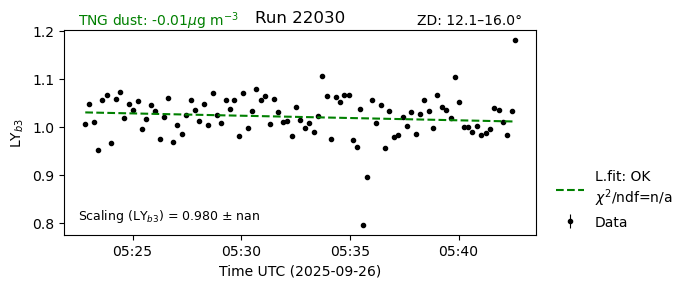

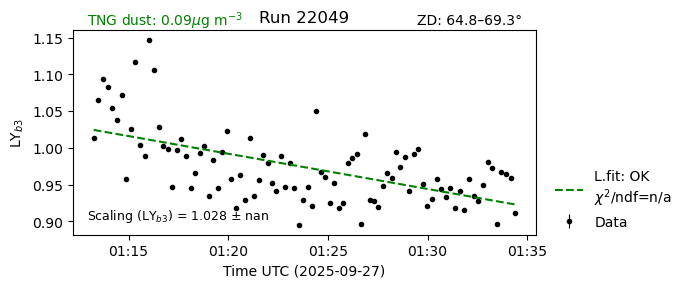

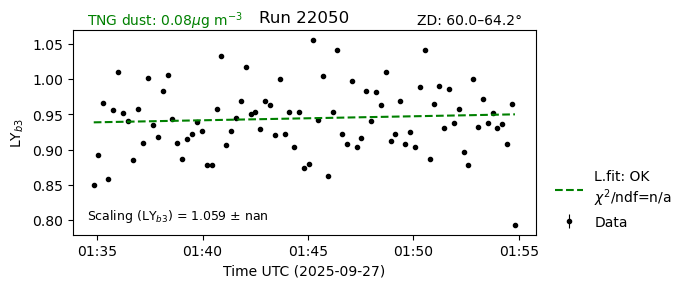

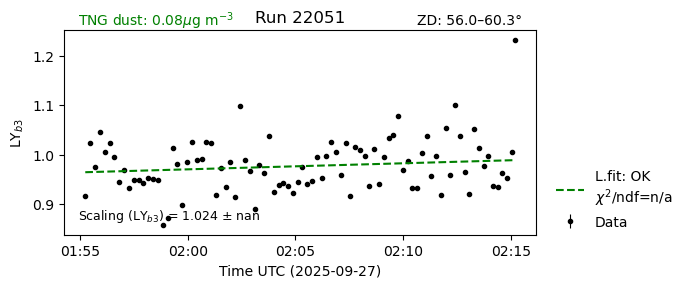

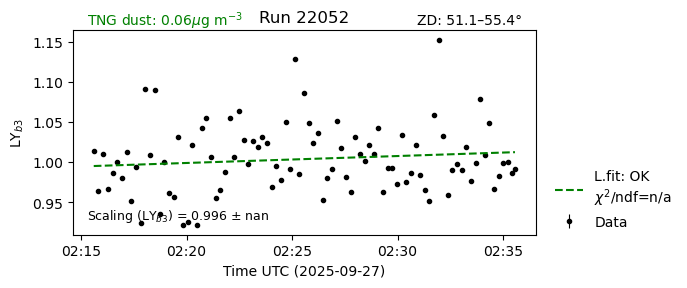

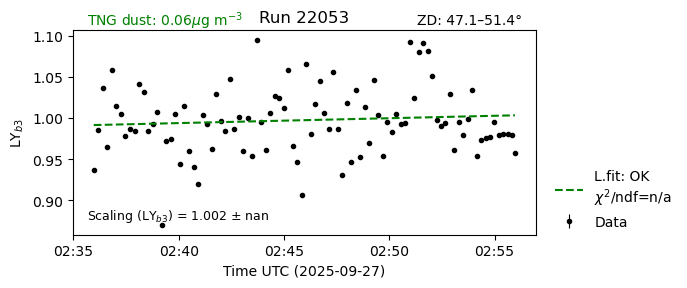

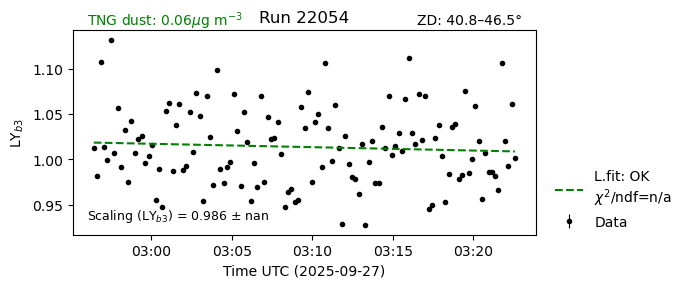

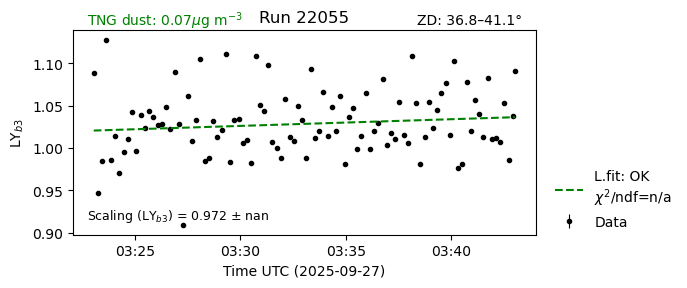

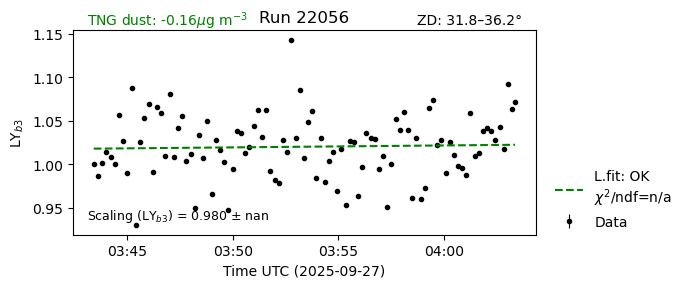

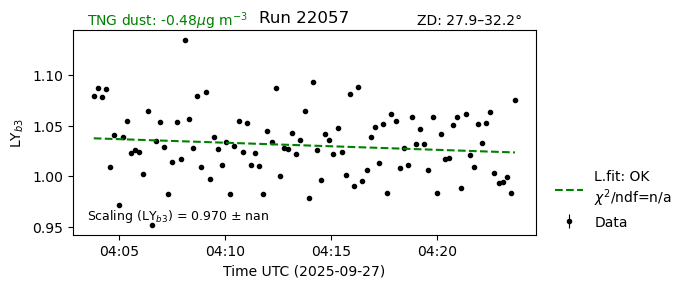

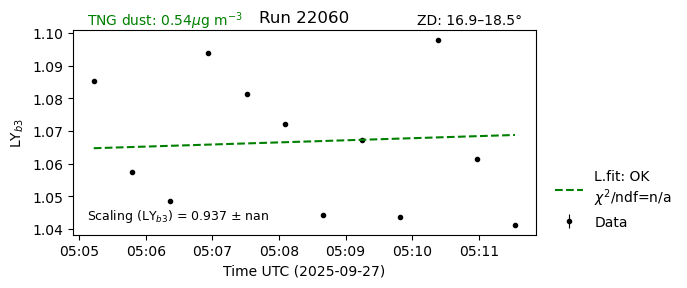

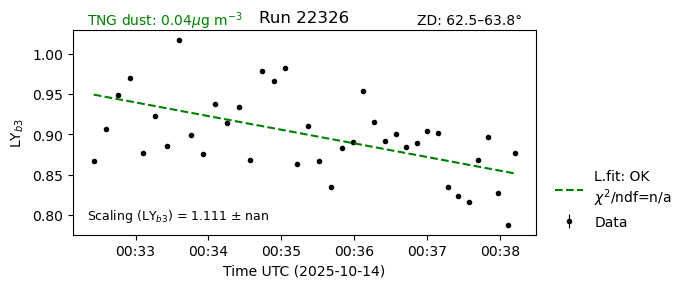

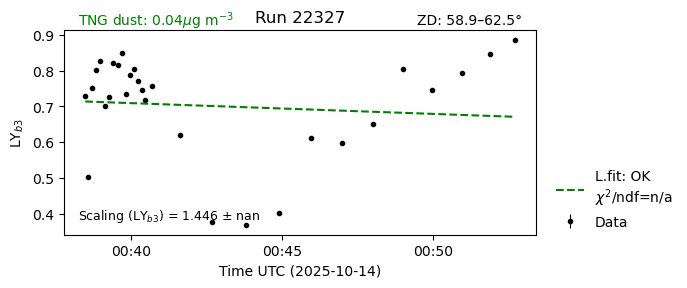

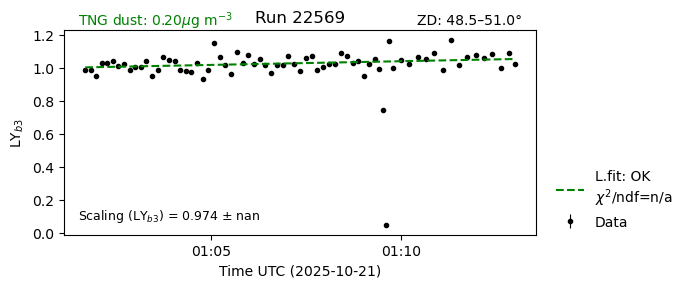

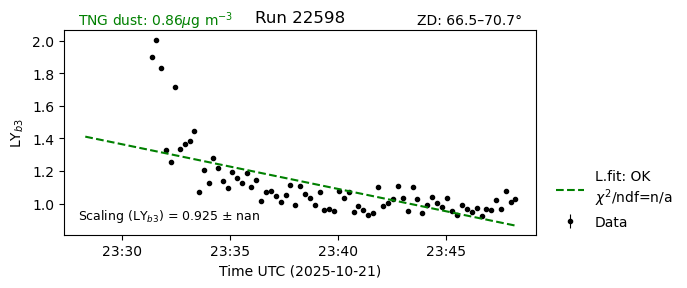

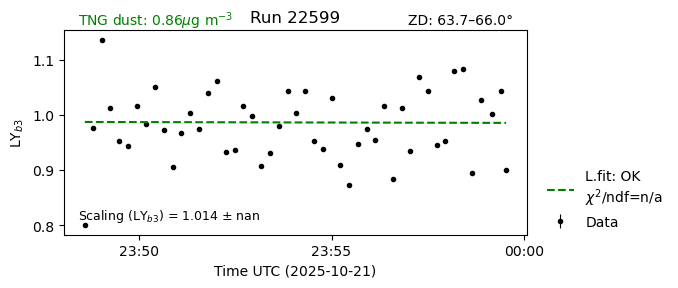

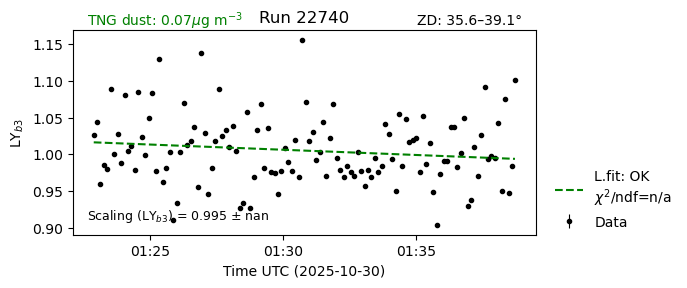

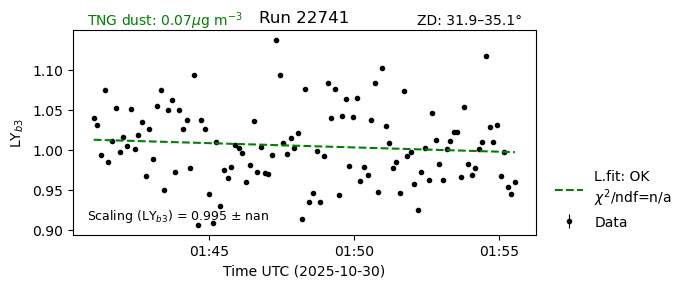

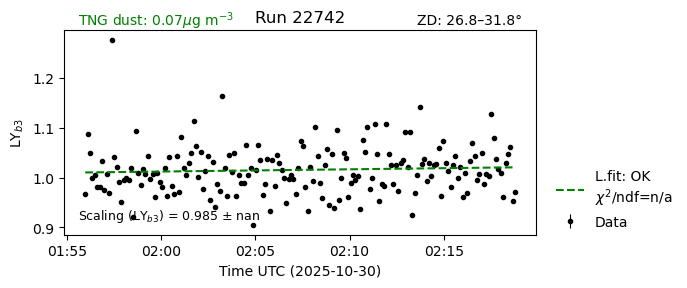

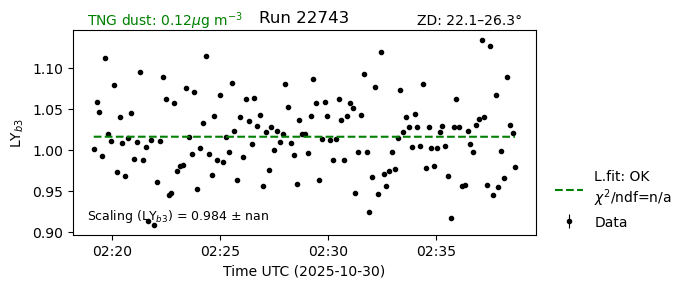

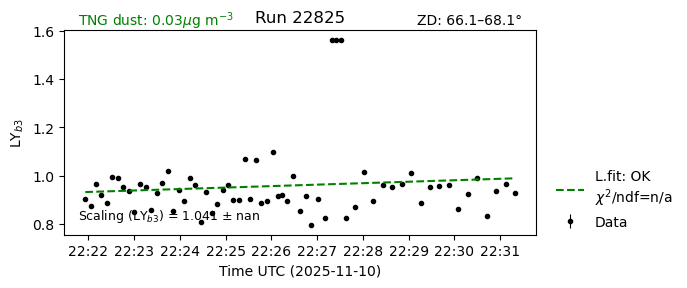

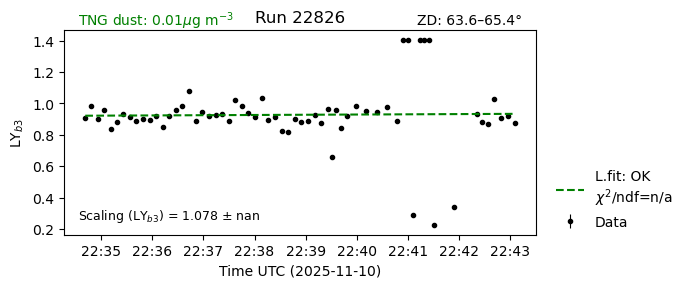

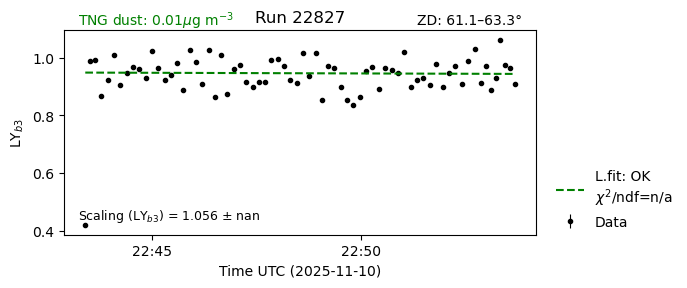

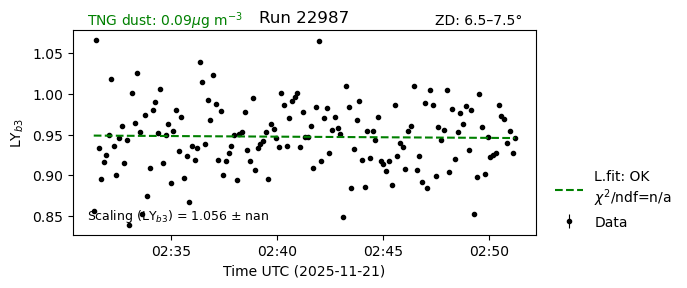

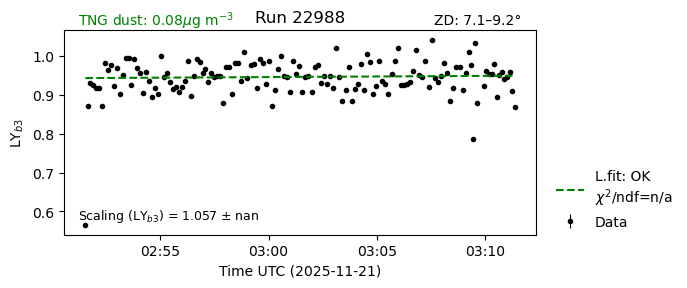

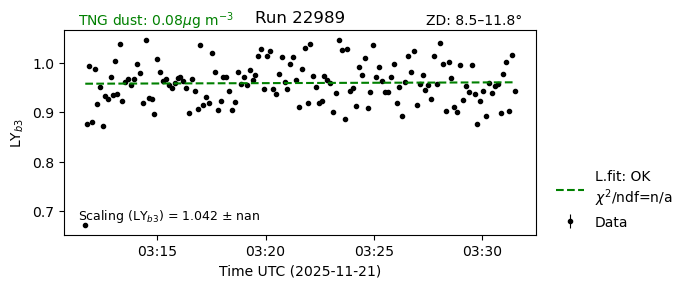

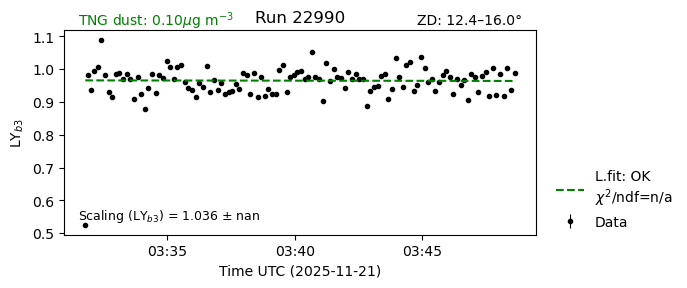

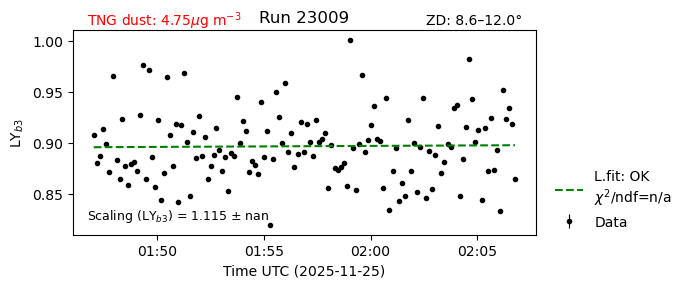

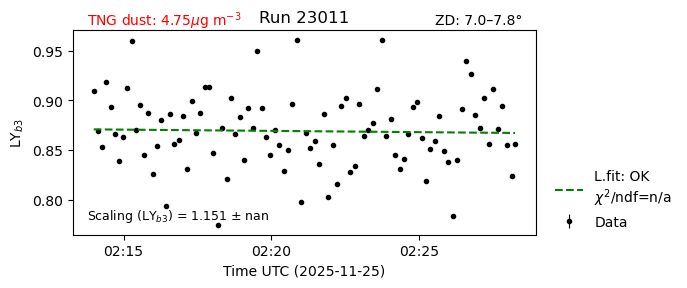

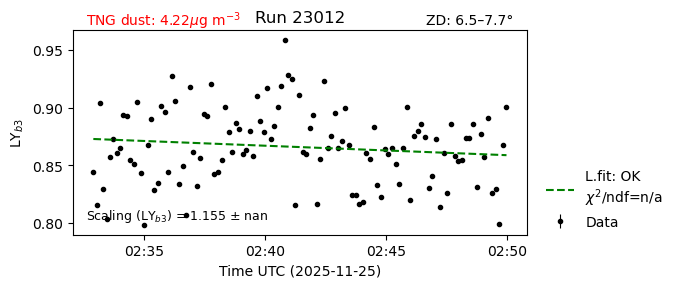

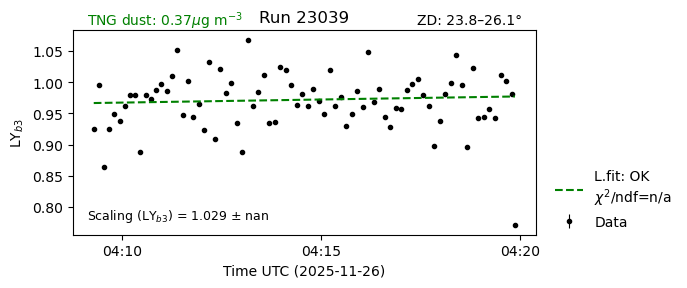

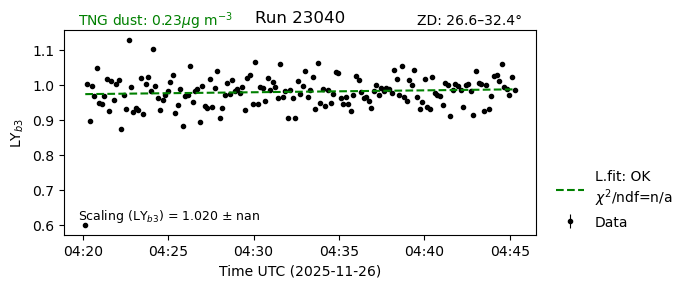

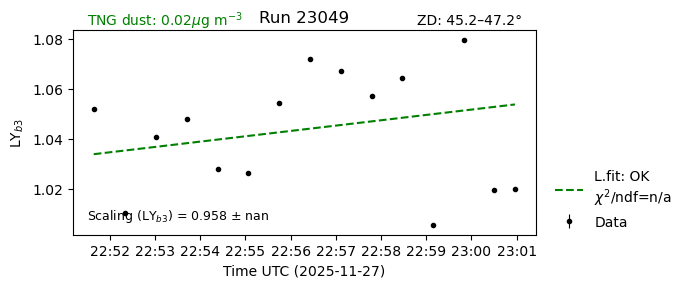

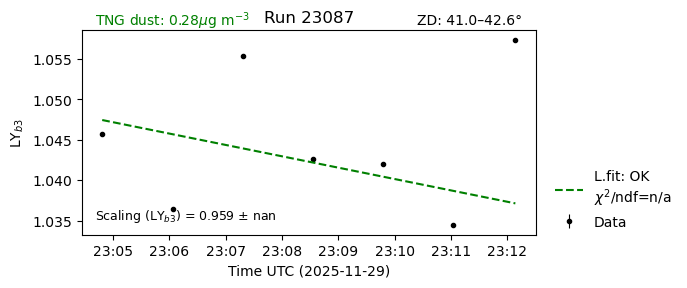

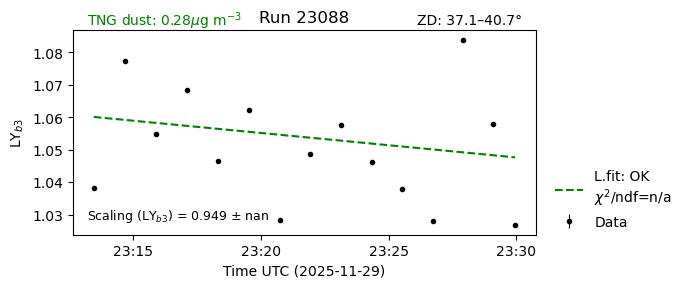

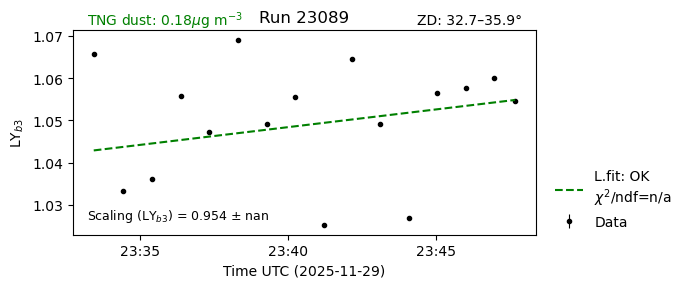

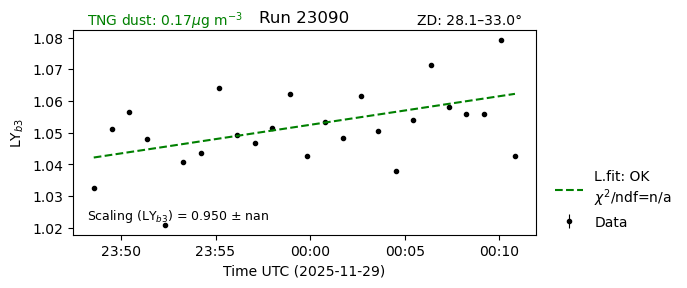

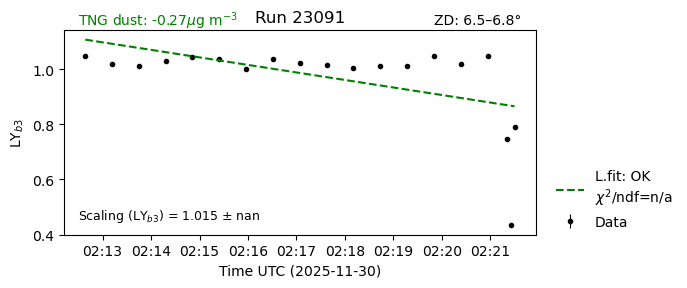

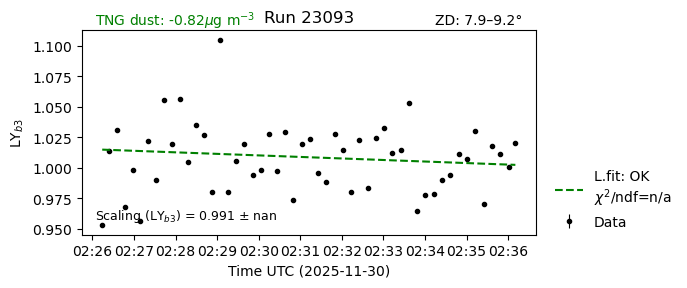

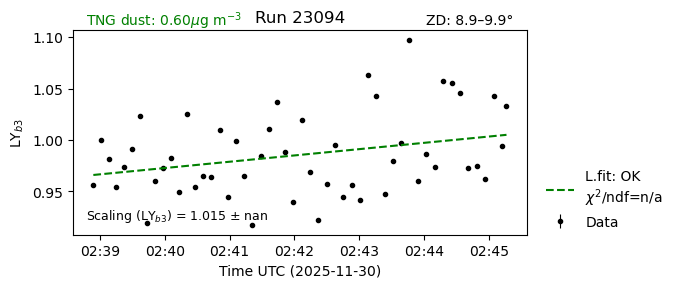

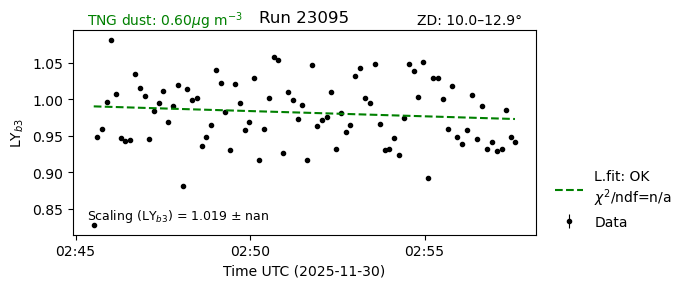

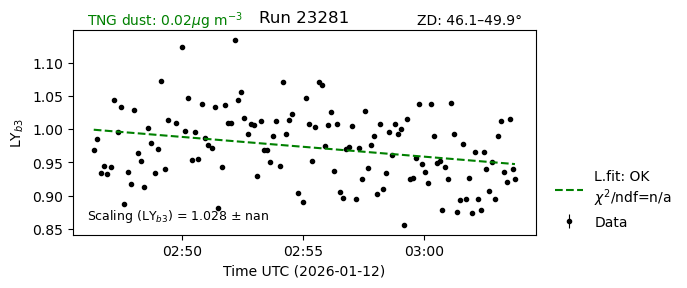

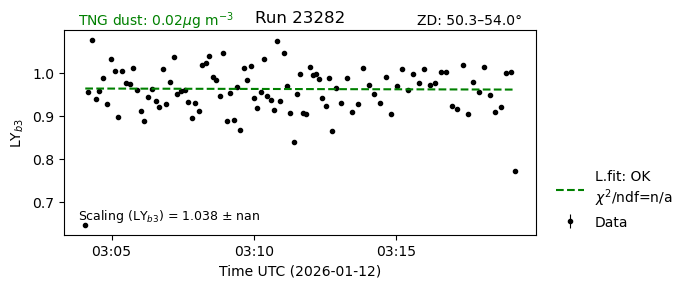

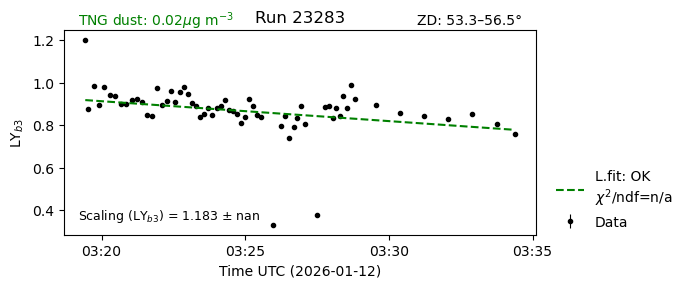

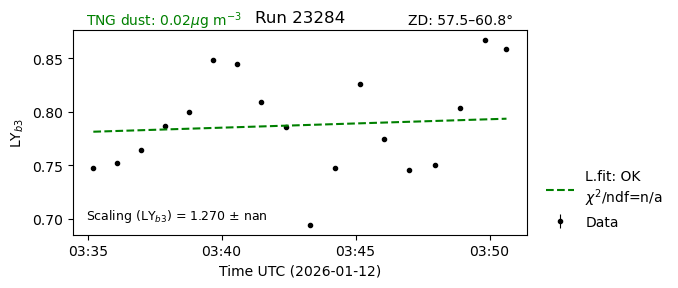

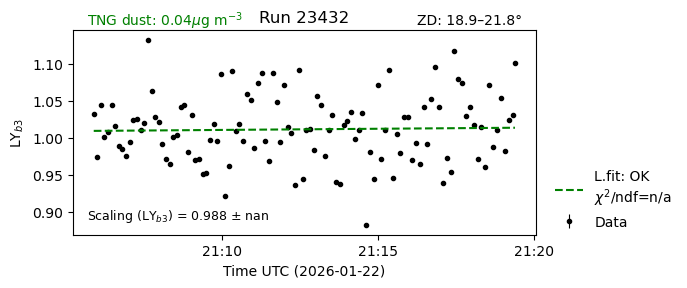

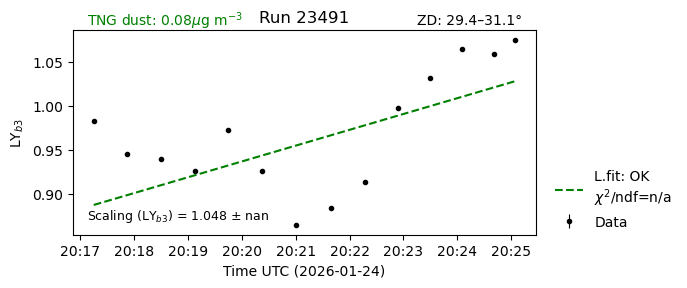

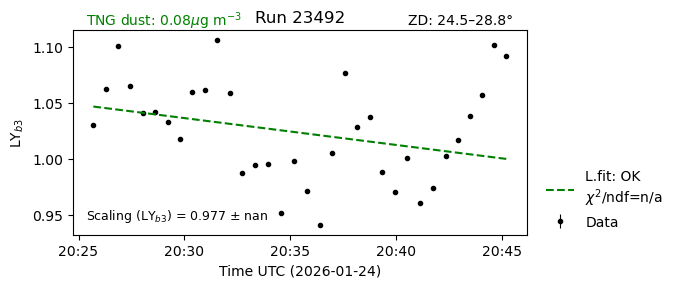

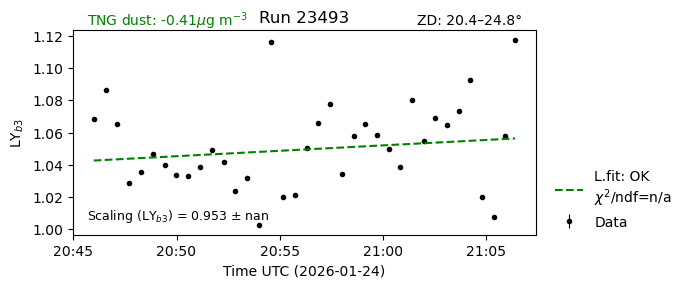

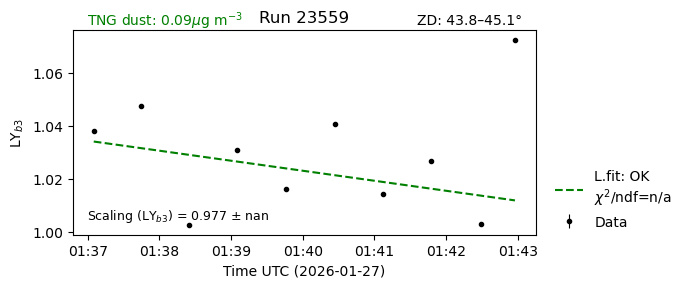

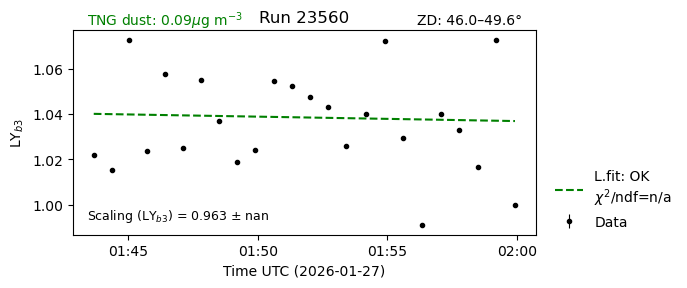

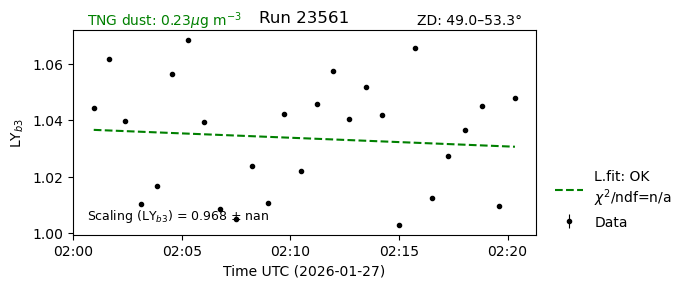

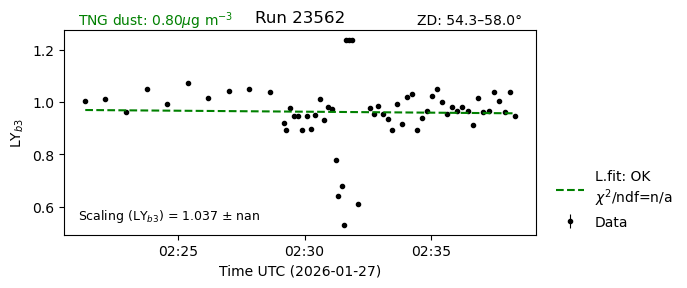

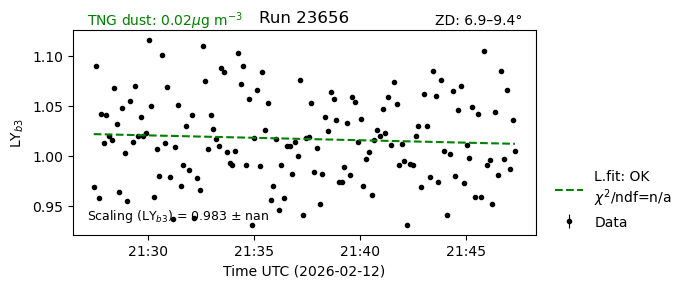

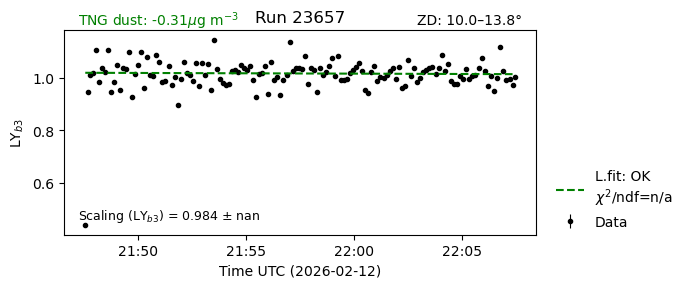

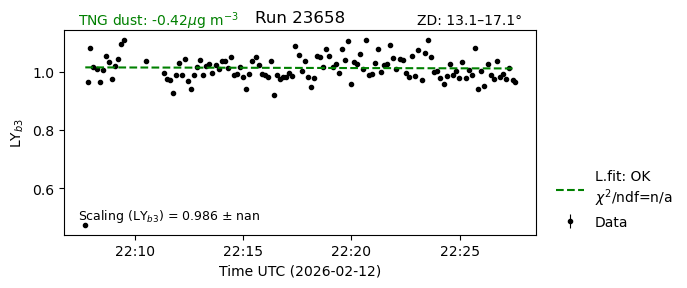

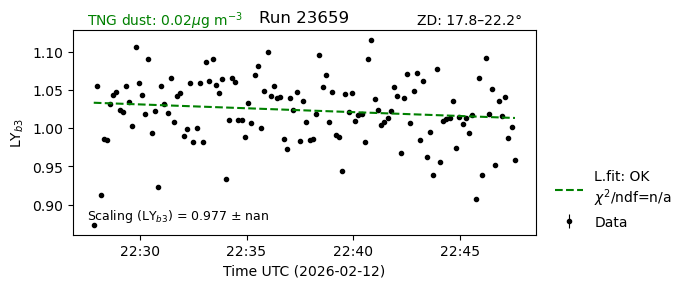

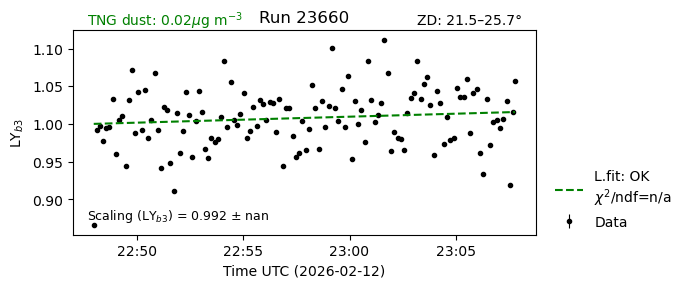

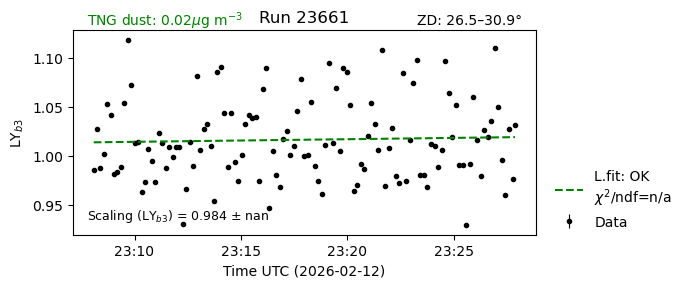

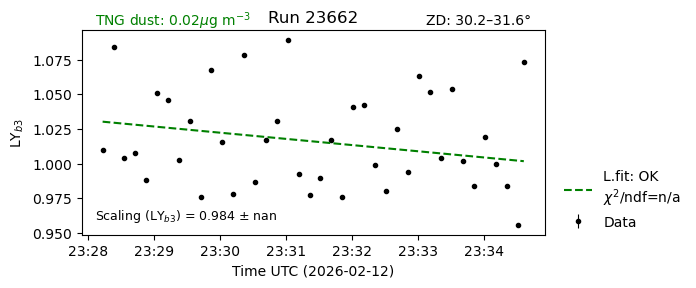

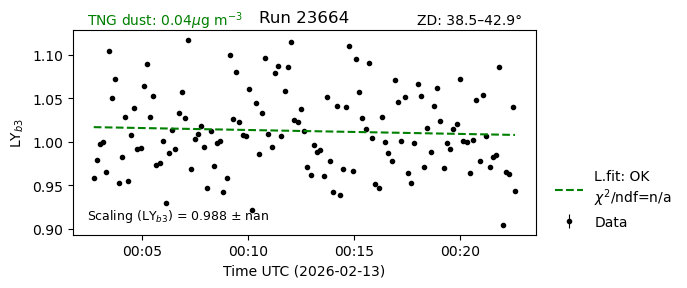

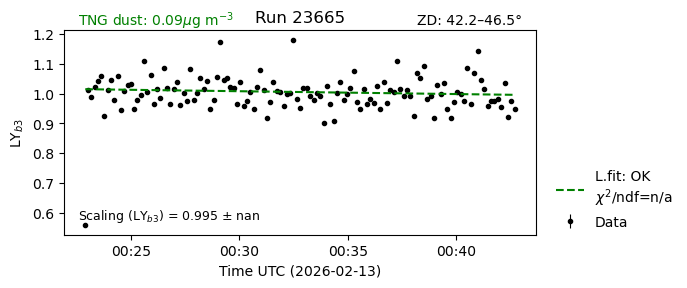

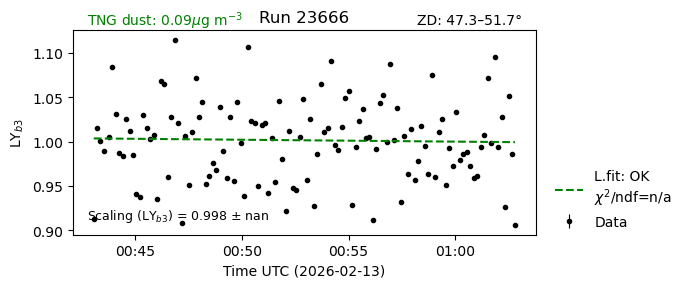

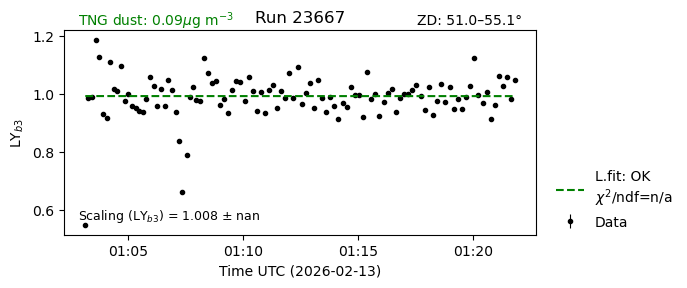

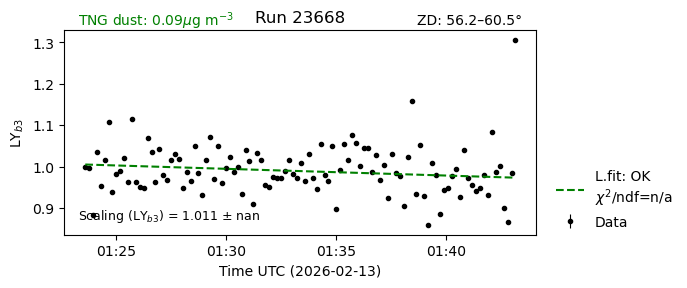

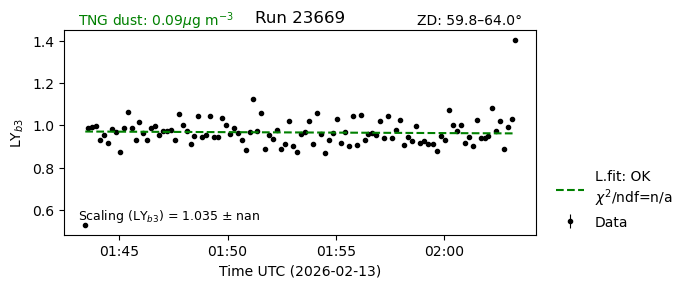

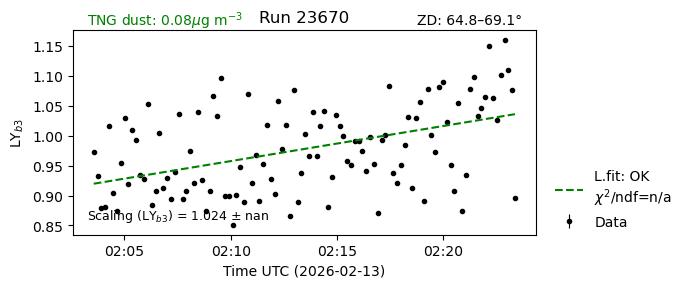

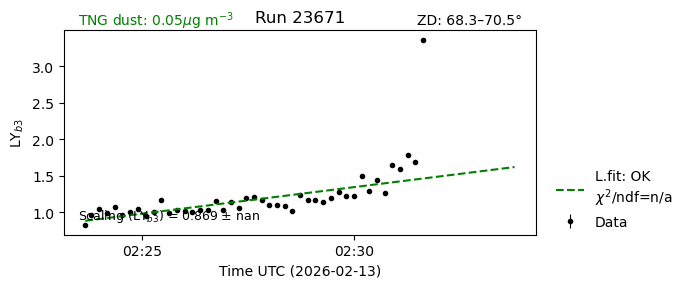

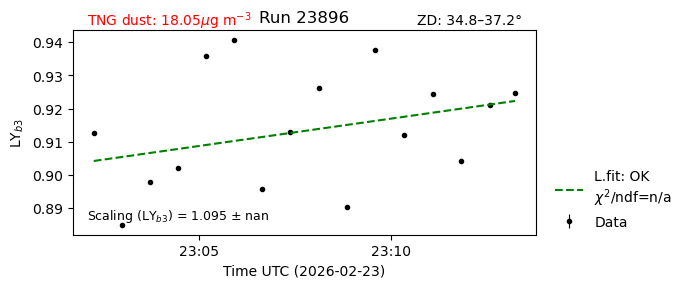

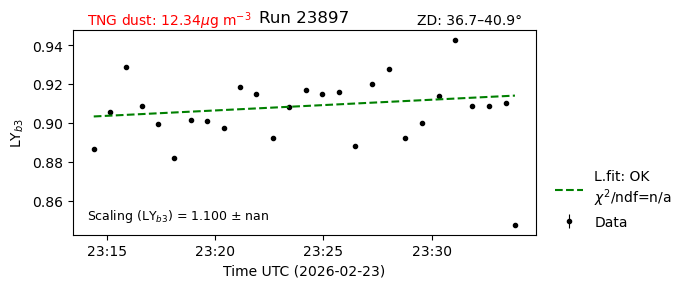

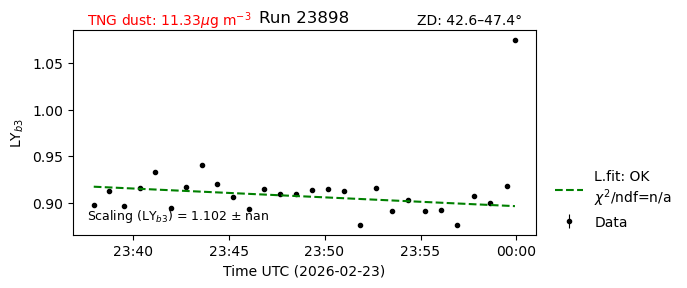

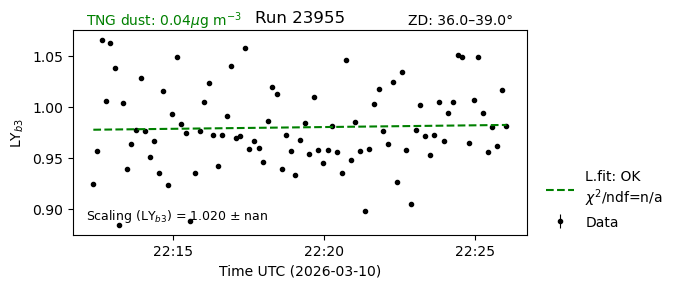

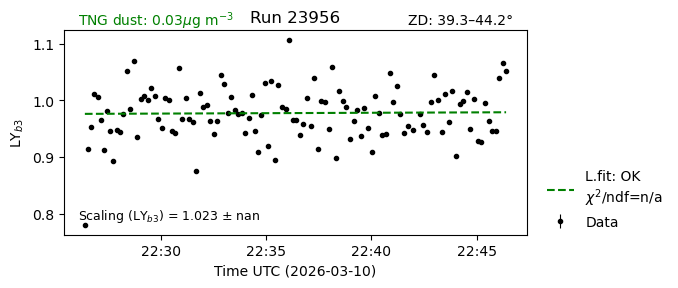

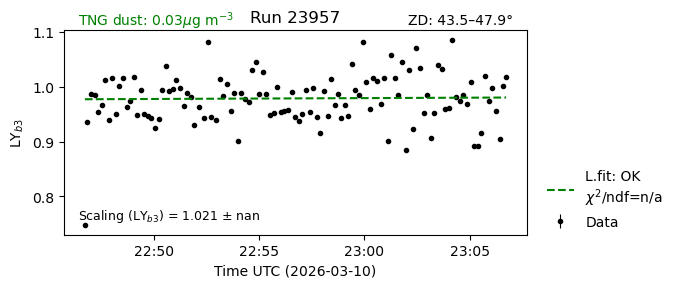

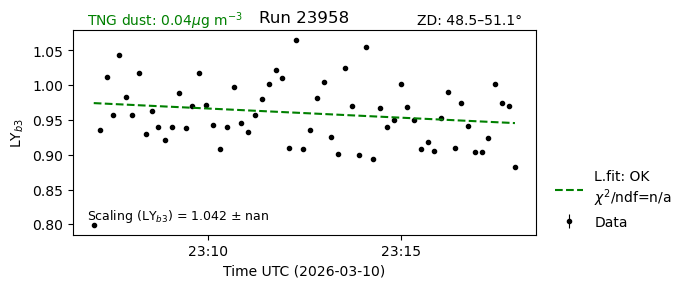

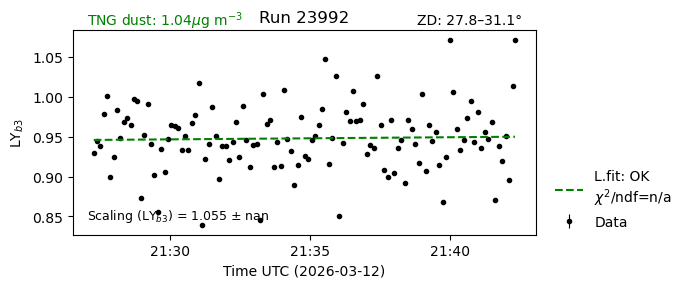

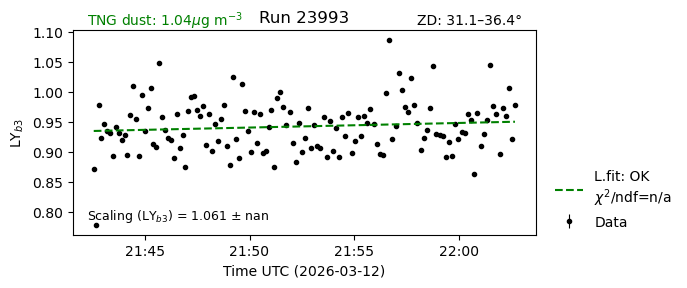

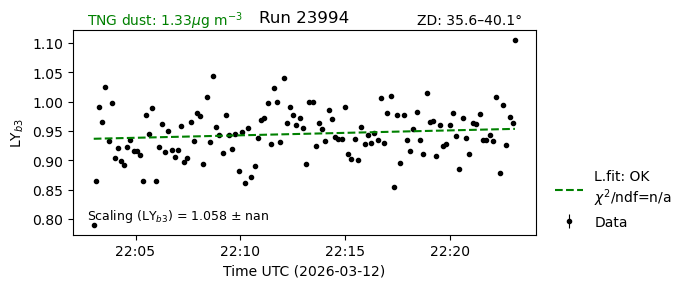

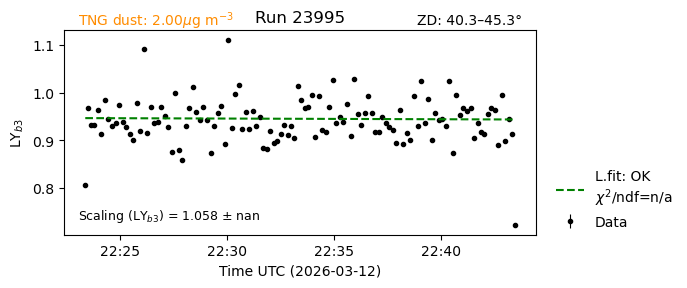

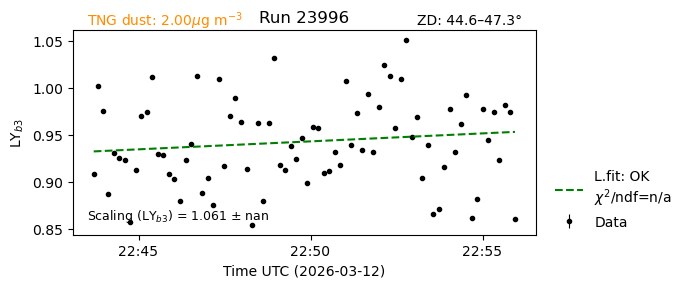

In [12]:
if not FNAME_DCHECK_FLAT_SRUNWISE.exists():
    print(f"Flat parquet not found at {FNAME_DCHECK_FLAT_SRUNWISE}, skipping run-wise plots.")
else:
    df_flat = pd.read_parquet(FNAME_DCHECK_FLAT_SRUNWISE)
    df_flat["time"] = pd.to_datetime(df_flat["time"])

    ly_label = "LY$_i$" if LY_SOURCE == "ly_i" else "LY$_{b3}$"
    ly_err_col = f"{LY_SUBRUN_COL}_err"

    for _, row in df_sel.iterrows():
        run_id = int(row["obs_id"])
        tab = df_flat[df_flat["obs_id"] == run_id].copy()
        if tab.empty:
            print(f"  Run {run_id}: no subrun data found in flat parquet - skipping.")
            continue

        # ── Build arrays ────────────────────────────────────────────────
        pd_time      = pd.to_datetime(tab["time"])
        dtime        = pd_time.to_numpy()
        # Elapsed seconds since this run's first subrun -- MUST match the x-axis
        # fit_p0/fit_p1 were actually computed against upstream (t = (t_abs -
        # t_abs.min()) / np.timedelta64(1, "s")). Using raw Unix epoch time (or
        # epoch/1e9) here evaluates the stored fit on a totally different x-scale
        # than it was fit on, which is why the line comes out flat/far from the data.
        t_elapsed    = (dtime - dtime.min()) / np.timedelta64(1, "s")
        charge_yield = tab[LY_SUBRUN_COL].to_numpy(dtype=float)
        charge_yield_err = (tab[ly_err_col].to_numpy(dtype=float)
                             if ly_err_col in tab.columns else np.full_like(charge_yield, np.nan))
        dust_value   = float(row["tng_dust"]) if "tng_dust" in row and not pd.isna(row["tng_dust"]) else np.nan
        zd_min = float(row["min_zd"]) if "min_zd" in row and not pd.isna(row["min_zd"]) else np.nan
        zd_max = float(row["max_zd"]) if "max_zd" in row and not pd.isna(row["max_zd"]) else np.nan

        # ── Precomputed fit & scaling (NOT computed here) ──────────────────
        fit_p0   = row[LY_FIT_P0_COL]
        fit_p1   = row[LY_FIT_P1_COL]
        fit_chi2 = row[LY_FIT_CHI2_COL]
        fit_ndf  = row[LY_FIT_NDF_COL]
        error_flag_raw = row[LY_FIT_ERR_FLAG]
        fit_error_flag = bool(error_flag_raw) if not pd.isna(error_flag_raw) else True
        fit_successful = (not fit_error_flag) and (not pd.isna(fit_p0)) and (not pd.isna(fit_p1))

        scaling     = row[LY_SCALING_COL]
        scaling_err = row[LY_SCALING_ERR_COL]

        y_median = np.nanmedian(charge_yield)

        # ── Plot ─────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 3))

        # subrun data as dots with (possibly NaN) error bars
        ax.errorbar(dtime, charge_yield, yerr=charge_yield_err, ls="none", marker="o", ms=3,
                    color="k", ecolor="k", elinewidth=0.8, capsize=0, zorder=-10, label="Data")

        # ── Fit line x-points, built from the precomputed p0/p1 ────────────
        if len(t_elapsed) > 0 and not np.isnan(t_elapsed).all():
            xarray_ts = np.linspace(np.nanmin(t_elapsed), np.nanmax(t_elapsed), 200)
            xarray = (pd_time.min() + pd.to_timedelta(xarray_ts, unit="s")).to_numpy()
        else:
            xarray, xarray_ts = np.array([]), np.array([])
            
        
        if fit_successful:
            chi2_ndf_str = f"{fit_chi2/fit_ndf:.0e}" if not pd.isna(fit_chi2) and fit_ndf else "n/a"
            fit_label = f"L.fit: OK\n$\\chi^2$/ndf={chi2_ndf_str}"
            ax.plot(xarray, utils.straight_line(xarray_ts, fit_p0, fit_p1), color="g", ls="--", label=fit_label)
        else:
            chi2_ndf_str = f"{fit_chi2/fit_ndf:.0e}" if not pd.isna(fit_chi2) and fit_ndf else None
            fit_label = f"L.fit: not OK\n$\\chi^2$/ndf={chi2_ndf_str}" if chi2_ndf_str else "L.fit: not OK"
            if not pd.isna(fit_p0) and not pd.isna(fit_p1):
                ax.plot(xarray, utils.straight_line(xarray_ts, fit_p0, fit_p1), color="r", ls="--", label=fit_label)
            else:
                ax.plot([], [], color="r", ls="--", label=fit_label)
            ax.axhline(y_median, color="darkorange", ls=":", label=f"Using median\n{y_median:.3f}")

        ax.legend(frameon=False, loc=(1.03, 0))

        # Scaling factor: lower-left corner, inside the axes
        scaling_str = f"Scaling ({ly_label}) = {scaling:.3f} ± {scaling_err:.3f}" if not pd.isna(scaling) else f"Scaling ({ly_label}) = n/a"
        ax.text(0.03, 0.05, scaling_str, ha="left", va="bottom", transform=ax.transAxes, fontsize=9, color="k")

        # Dust: top-left, above the axes
        if not np.isnan(dust_value):
            cdust = "r" if dust_value > 3.0 else "g" if dust_value < 1.5 else "darkorange"
            ax.text(0.03, 1.05, f"TNG dust: {dust_value:.2f}" + "$\\mu$g m$^{-3}$",
                ha="left", va="center", transform=ax.transAxes, color=cdust,)

        # Zenith distance range: top-right, above the axes, mirroring dust (plain black)
        if not (np.isnan(zd_min) or np.isnan(zd_max)):
            ax.text(0.97, 1.05, f"ZD: {zd_min:.1f}–{zd_max:.1f}°",
                ha="right", va="center", transform=ax.transAxes, color="k",)

        ax.set(xlabel=f"Time UTC ({pd.Timestamp(dtime[0]).date()})", ylabel=ly_label, title=f"Run {run_id}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        plt.tight_layout()
        plt.show()

## Step 10 - Manual discard

Applies `MANUAL_DISCARD_RUNS` (set in the config cell, after inspecting the
plots in Step 9) to the candidate list, producing the definitive `df_final`
used for everything below.

In [13]:
MANUAL_DISCARD_RUNS = [22983]

In [14]:
print(f"Candidate runs before manual discard: {len(df_sel):,}")

if MANUAL_DISCARD_RUNS:
    print(f"Manually discarding {len(MANUAL_DISCARD_RUNS)} run(s): {sorted(MANUAL_DISCARD_RUNS)}")
else:
    print("No runs manually discarded (MANUAL_DISCARD_RUNS is empty).")

mask_manual = ~df_sel["obs_id"].astype(int).isin(MANUAL_DISCARD_RUNS)
n_discarded = int((~mask_manual).sum())

missing_ids = set(MANUAL_DISCARD_RUNS) - set(df_sel["obs_id"].astype(int))
if missing_ids:
    print(f"  Note: {sorted(missing_ids)} were listed in MANUAL_DISCARD_RUNS but are not in the "
          f"candidate list (already removed by an earlier cut) - nothing to do for these.")

df_final = df_sel[mask_manual].copy().sort_values("time").reset_index(drop=True)

print(f"\nDefinitive run list: {len(df_final):,} runs  ({n_discarded} discarded manually)")
print(f"Total elapsed time : {df_final['corrected_elapsed_time'].sum()/3600:.2f} h")


Candidate runs before manual discard: 112
Manually discarding 1 run(s): [22983]
  Note: [22983] were listed in MANUAL_DISCARD_RUNS but are not in the candidate list (already removed by an earlier cut) - nothing to do for these.

Definitive run list: 112 runs  (0 discarded manually)
Total elapsed time : 32.10 h


## Step 11 - Final selection summary plots

Overview of the definitive run list: the chosen light-yield source and its
scaling factor over time (candidates in gray, final selection in blue,
manually-discarded runs circled in red), and the scaling-factor distribution
of the final selection.

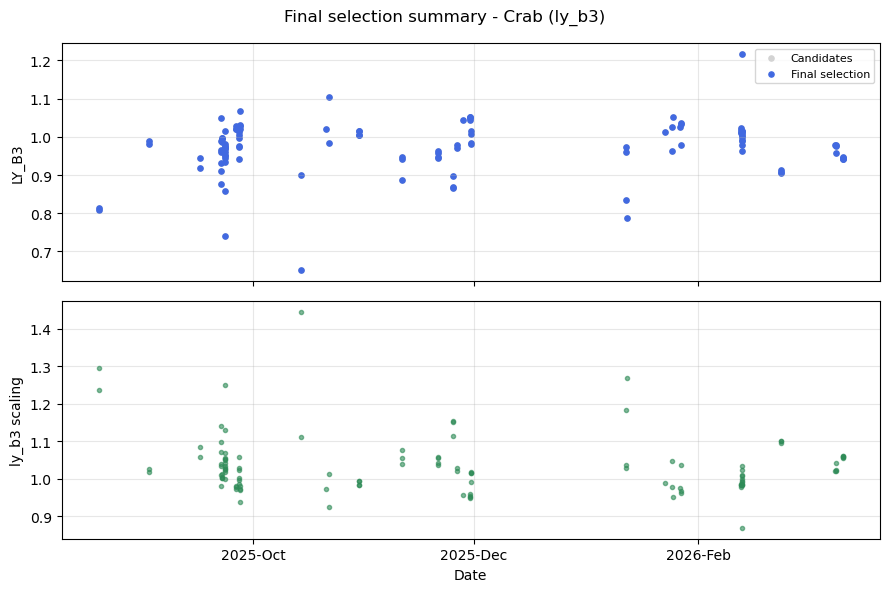

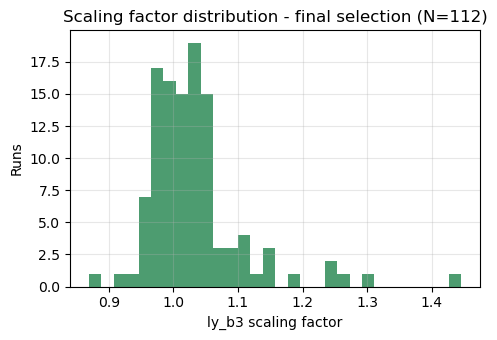

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

discarded = df_sel[df_sel["obs_id"].astype(int).isin(MANUAL_DISCARD_RUNS)]

# Panel 1 – LY_SOURCE per-run value over time
axes[0].scatter(df_sel["time"], df_sel[LY_SOURCE], s=14, color="lightgray", label="Candidates")
axes[0].scatter(df_final["time"], df_final[LY_SOURCE], s=14, color="royalblue", label="Final selection")
if not discarded.empty:
    axes[0].scatter(discarded["time"], discarded[LY_SOURCE], s=50, facecolors="none",
                     edgecolors="red", linewidths=1.5, label="Manually discarded")
axes[0].set(ylabel=LY_SOURCE.upper())
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Panel 2 – scaling factor over time (final selection only)
axes[1].errorbar(df_final["time"], df_final[LY_SCALING_COL], yerr=df_final[LY_SCALING_ERR_COL],
                  fmt="o", ms=3, color="seagreen", ecolor="seagreen", alpha=0.6, capsize=0)
axes[1].set(ylabel=f"{LY_SOURCE} scaling", xlabel="Date")
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%b"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

fig.suptitle(f"Final selection summary - {SOURCE_NAME} ({LY_SOURCE})")
plt.gcf().autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

# Scaling factor distribution
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(df_final[LY_SCALING_COL].dropna(), bins=30, color="seagreen", alpha=0.85, edgecolor="none")
ax.set(xlabel=f"{LY_SOURCE} scaling factor", ylabel="Runs",
       title=f"Scaling factor distribution - final selection (N={len(df_final)})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 12 - Export definitive run list (single file)

Exports **one** CSV containing the full definitive run list (`df_final`),
keeping every column already present in the datacheck table (quality
variables, pointing, both LY_i and LY_b3 fit/scaling info, etc.) plus a couple
of small bookkeeping columns recording which scaling source was used for this
selection.

Saved 112 selected runs -> /fefs/aswg/workspace/juan.jimenez/lstreco/cherenkov-corrections/data/selection/selected_runs.csv

── Selection summary ────────────────────────────────────────────────
  Source              : Crab
  LY scaling source   : ly_b3
  Wobble distance     : 0.4 deg
  Date range applied  : 2025-08-17 00:00:00  ->  None
  Dust cut (DUST_MAX) : None ug/m3
  NSB cut  (NSB_MAX)  : None
  ZD cut   (ZD_MAX)   : None deg
  Elapsed time cut    : 120.0 - 2500.0 s
  Manually discarded  : [22983]
  ─────────────────────────────────────
  Input runs          : 13,661
  Candidate runs      : 112
  Final selected runs : 112  (0.8% of input)
  Total elapsed time  : 32.10 h
  Total subruns       : 10,250
─────────────────────────────────────────────────────────────────────


,mean,std,min,max
obs_id,22798.339286,779.671894,21404.0,23996.0
n_subruns,91.517857,45.932183,7.0,191.0
time,2025-11-25 06:18:05.390321664,NaN,2025-08-19 05:01:18.438055,2026-03-12 22:43:41.889961
elapsed_time,1036.318646,358.483195,353.475095,3058.323276
corrected_elapsed_time,1031.92937,355.655656,353.475095,2963.520255
...,...,...,...,...
ly_b3_p_value,0.520203,0.060728,0.357218,0.797624
ly_b3_err,NaN,NaN,NaN,NaN
separation_deg,0.398061,0.01123,0.35982,0.430885
ly_b3_scaling_used,1.034078,0.078006,0.869348,1.445701


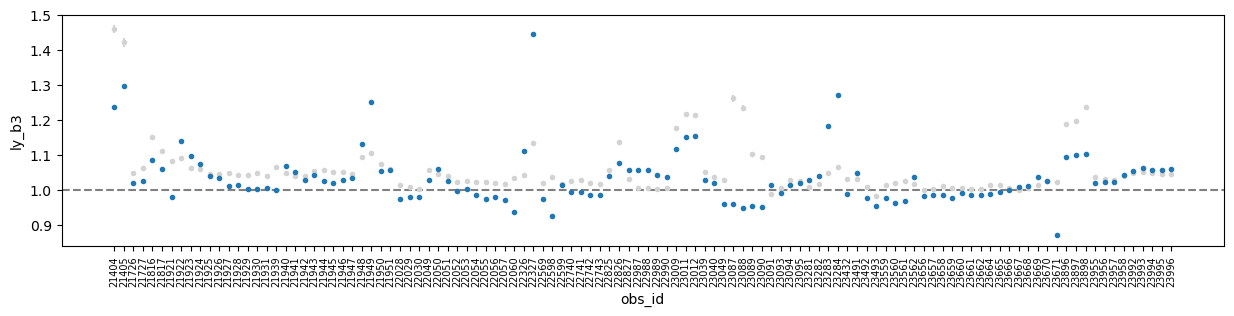

In [25]:
# Bookkeeping columns so the exported file is self-describing
df_final["ly_source_used"] = LY_SOURCE
df_final[f"{LY_SOURCE}_scaling_used"] = df_final[LY_SCALING_COL]
df_final[f"{LY_SOURCE}_scaling_used_err"] = df_final[LY_SCALING_ERR_COL]

df_final.to_csv(FNAME_SELECTED_RUNS, index=False)
print(f"Saved {len(df_final):,} selected runs -> {FNAME_SELECTED_RUNS}")

print("\n── Selection summary ────────────────────────────────────────────────")
print(f"  Source              : {SOURCE_NAME}")
print(f"  LY scaling source   : {LY_SOURCE}")
print(f"  Wobble distance     : {WOBBLE_DISTANCE}")
print(f"  Date range applied  : {DATE_MIN}  ->  {DATE_MAX}")
print(f"  Dust cut (DUST_MAX) : {DUST_MAX} ug/m3")
print(f"  NSB cut  (NSB_MAX)  : {NSB_MAX}")
print(f"  ZD cut   (ZD_MAX)   : {ZD_MAX} deg")
print(f"  Elapsed time cut    : {ELAPSED_TIME_MIN} - {ELAPSED_TIME_MAX} s")
print(f"  Manually discarded  : {sorted(MANUAL_DISCARD_RUNS) if MANUAL_DISCARD_RUNS else '(none)'}")
print(f"  ─────────────────────────────────────")
print(f"  Input runs          : {len(df):,}")
print(f"  Candidate runs      : {len(df_sel):,}")
print(f"  Final selected runs : {len(df_final):,}  ({len(df_final)/len(df)*100:.1f}% of input)")
print(f"  Total elapsed time  : {df_final['corrected_elapsed_time'].sum()/3600:.2f} h")
print(f"  Total subruns       : {df_final['n_subruns'].sum():,}")
print("─────────────────────────────────────────────────────────────────────")

display(df_final.describe().T[["mean", "std", "min", "max"]])

fig, ax = plt.subplots(figsize=(15, 3))
ax.set(ylabel=f"{LY_SOURCE}", xlabel="obs_id")
plt.errorbar(np.array(df_final["obs_id"], dtype=str), df_final["ly_i_scaling"],  yerr=df_final["ly_i_scaling_err"], marker=".", ls="", color="lightgray")
plt.errorbar(np.array(df_final["obs_id"], dtype=str), df_final["ly_b3_scaling"],  yerr=df_final["ly_b3_scaling_err"], marker=".", ls="")
plt.axhline(1, color="0.5", ls="--")

ax.tick_params(axis="x", labelrotation=90, labelsize=7)
plt.show()